## Libaries

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd
import mne

parent_dir = Path().resolve().parent.parent
sys.path.append(str(parent_dir))

from src.utilities.preprocessing import Filtering, EEG_preprocessing, EMG_preprocessing       # noqa: E402
from src.utilities.load_and_visualize_data import load_datasets, visualize_EMG                    # noqa: E402

## Global variables

In [2]:
EMG_FREQ = 2000
EEG_FREQ = 125

EMG_LOWCUT = 20
EMG_HIGHCUT = 450
EEG_LOWCUT = 2
EEG_HIGHCUT = 32

EMG_NUM_CH = 3
EEG_NUM_CH = 16

NUM_EPOCHS = 30
TRIAL_PERIOD = 9
TRIM_PERIOD = 3

RMS_SAMPLING_WINDOW = 200
RMS_WINDOW_STEPSIZE = 50

EEG_CH_NAMES = [
    "Fp1", "Fp2",   # frontal pole
    "C3",  "C4",    # central
    "T5",  "T6",    # temporal (posterior)
    "Cz",  "Pz",    # occipital
    "F7",  "F8",    # temporal (anterior)
    "F3",  "F4",    # frontal
    "T3",  "T4",    # temporal (mid)
    "P3",  "P4"     # parietal
]
EMG_CH_NAMES = [
'Channel 1 : Flexor pollicis longus',
'Channel 2 : Flexor digitorum superficialis',
'Channel 3 : '
]

# EMG_CH_NAMES = [
# 'Channel 1 : Flexor digitorum superficialis',
# 'Channel 2 : Flexor pollicis longus', 
# 'Channel 3 : Extensor digitorum',
# 'Channel 4 : Extensor pollicis brevis/longus'
# ]

In [ ]:
# ----- Global style -----

plt.rcParams.update({
    # ---- Font ----
    "font.family": "serif",
    #"font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    #"mathtext.fontset": "stix",
    #"text.usetex": False,          # True for LaTeX rendering (optional)
    
    # ---- Font sizes (A4 layout, 10 pt doc) ----
    "font.size": 9,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    
    # ---- Line and color ----
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "lines.markersize": 4,
    "axes.prop_cycle": plt.cycler(color=plt.cm.tab10.colors),

    # ---- Layout ----
    # Page size (247.000, 174.000) height, width
    # (5.5, 3.5) half-page 
    #"figure.figsize": (5.5, 3.5),  
    "figure.dpi": 400,
    "savefig.transparent": True,
    "savefig.bbox": "tight"
})

## Load multiple csv files

In [3]:
#------------------------#
# Select what to inspect #
#------------------------#
base_dir = Path().resolve() / 'data'

load_ins = load_datasets(base_dir = base_dir)

EMG_index_files = load_ins.find_flex_files(
    subjects = 'subject_0_closedEyes',
    modality = 'EMG',
    fingers = 'index',
    prefix = 'flex'
)

EMG_thumb_files = load_ins.find_flex_files(
    subjects = 'subject_0_closedEyes',
    modality = 'EMG',
    fingers = 'thumb',
    prefix = 'flex'
)

## TRY OUT HAMPEL FILTER

In [22]:
from src.utilities.preprocessing import Filtering
data = None

data = pd.read_csv(EMG_index_files[1]).to_numpy()

print(data.shape)

EMG_filter_ins = Filtering(fs = EMG_FREQ)

EMG_notch = EMG_filter_ins.notch(data, cutoff=50, Q=30)
EMG_bandpass, _ = EMG_filter_ins.butter_bandpass(EMG_notch, lowcut = 20, highcut = 450, order=4)

# --------#
# 2) TRIM #
# --------#
trim_idx_102 = EMG_FREQ * TRIM_PERIOD
trim_idx_201 = (EMG_FREQ * 9 * NUM_EPOCHS) + trim_idx_102
EMG_trim = EMG_bandpass[trim_idx_102 : trim_idx_201, :]
print(f"Trim 102 idx {trim_idx_102}\n"
    f"Trim 201 idx {trim_idx_201}\n"
    f'EMG_trim shape: {EMG_trim.shape}\n')

n_samples = EMG_trim.shape[0]
cal_num_epochs = n_samples / (EMG_FREQ * 9)

if cal_num_epochs != 30:
    print('OBSERVATION - NUM OF EPOCH IS DIFFERNET FROM USUAL 30')

cal_num_epochs

(552000, 3)
Trim 102 idx 6000
Trim 201 idx 546000
EMG_trim shape: (540000, 3)



30.0

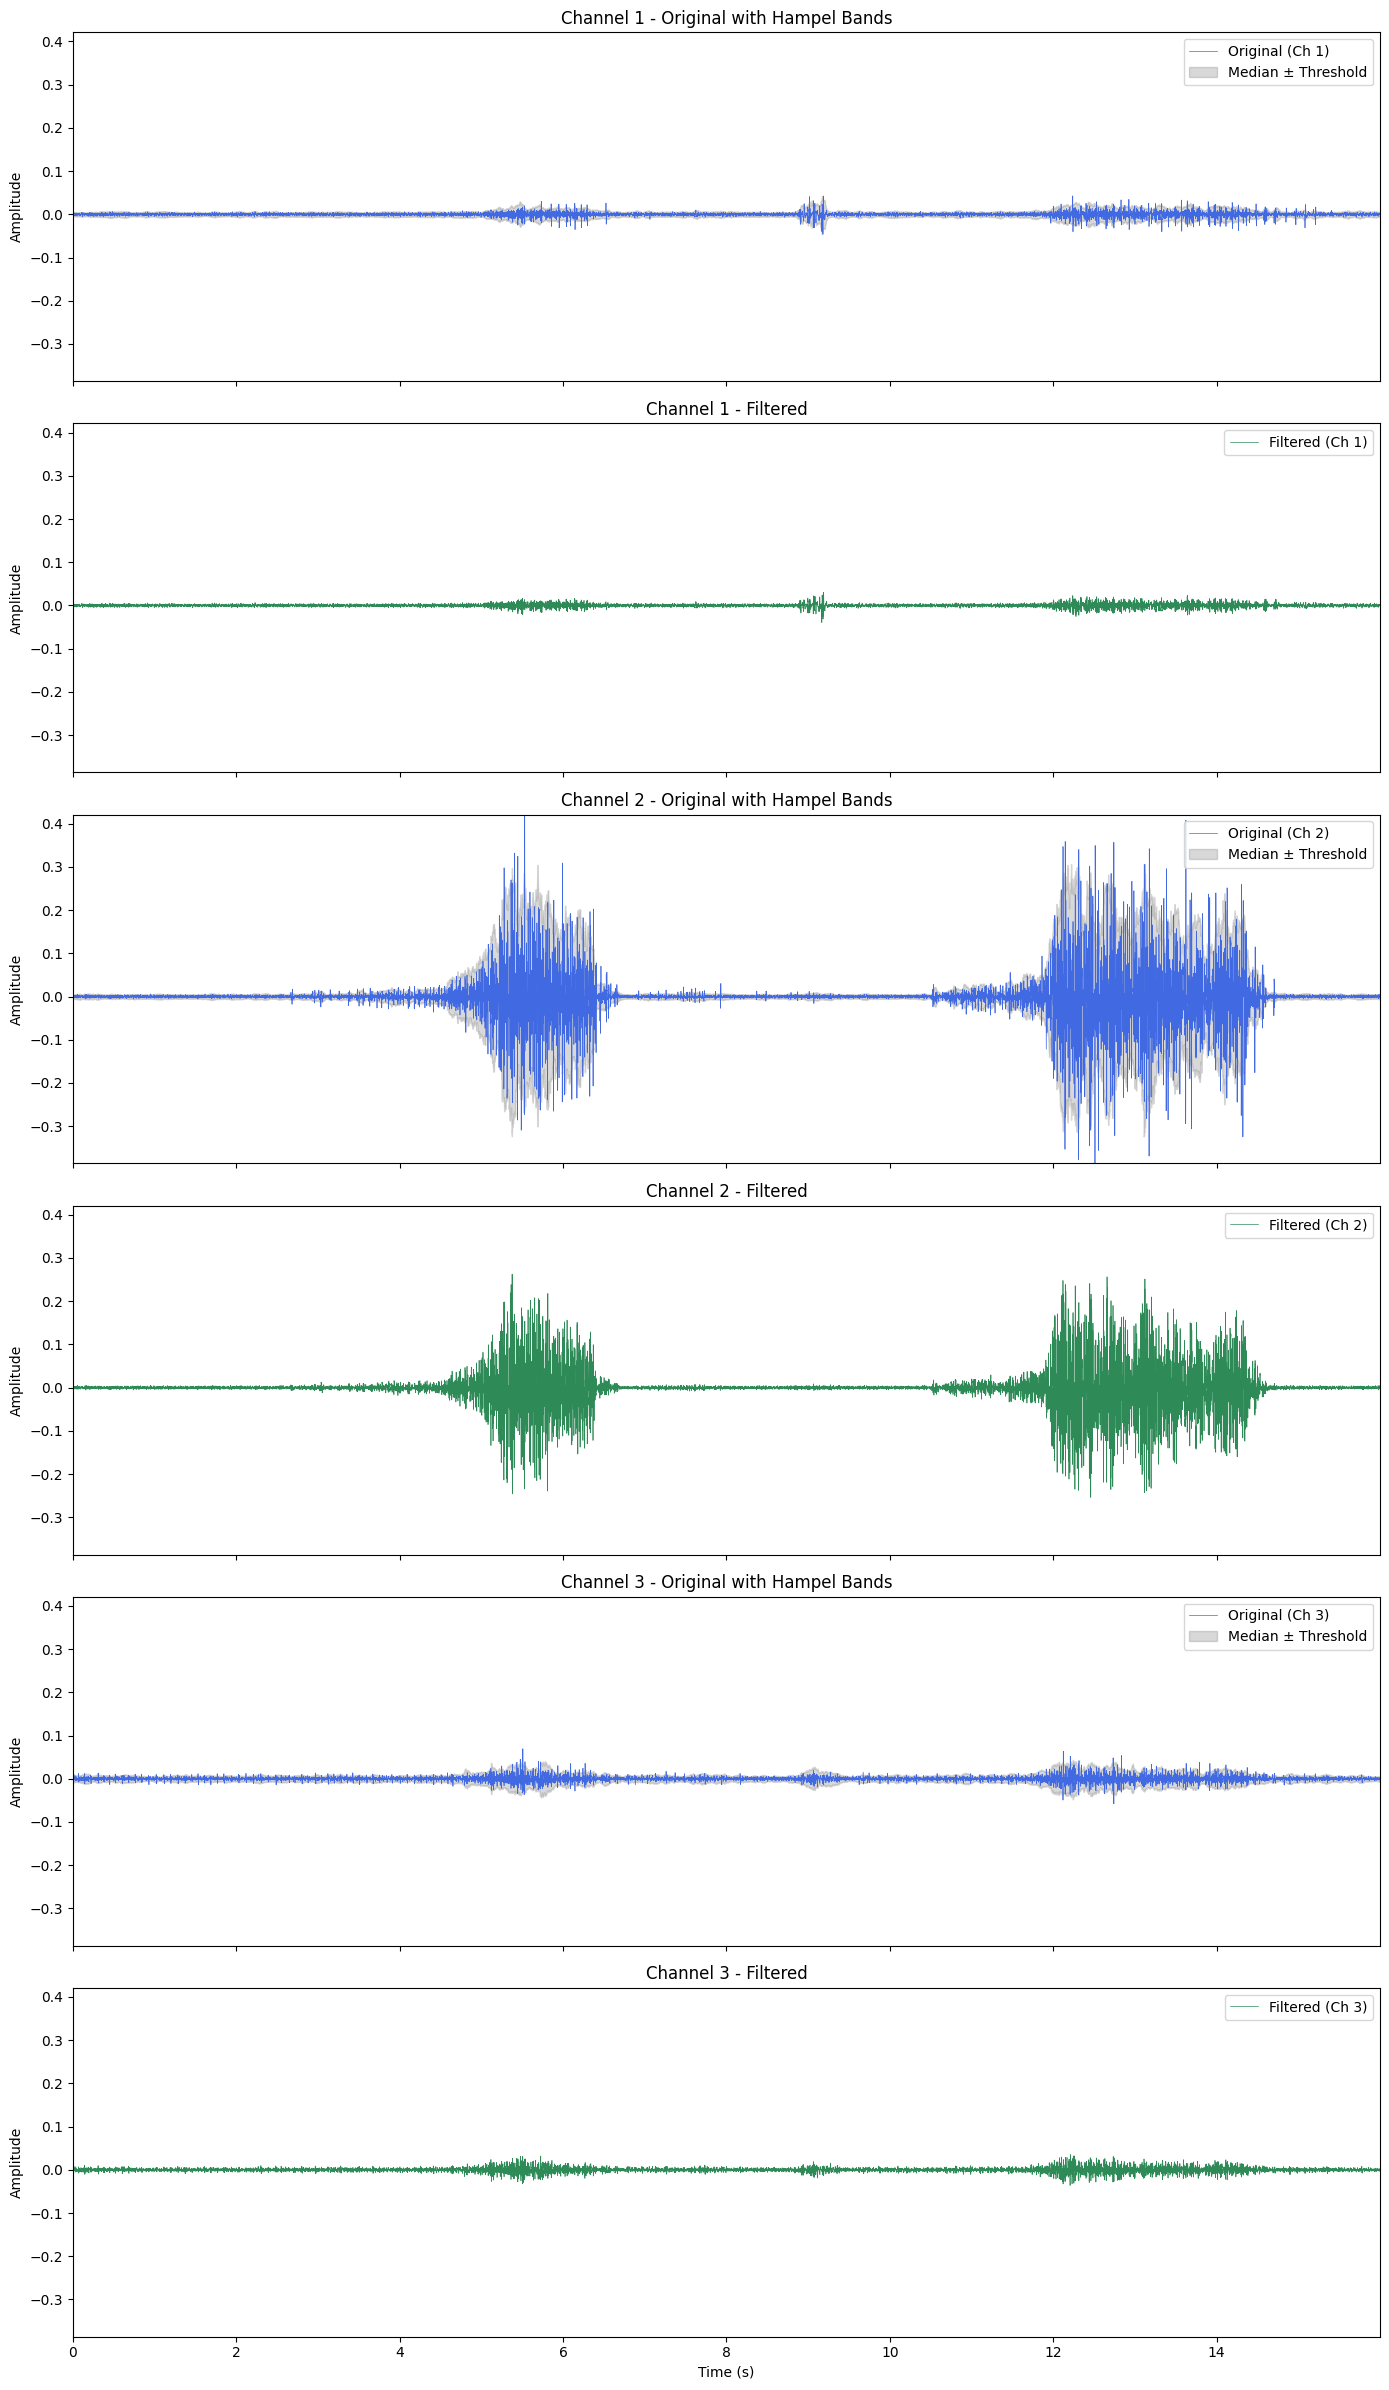

In [207]:
filtered_data = EMG_filt['filtered_data']
outlier_indices = EMG_filt['outlier_indices']
medians = EMG_filt['medians']
thresholds = EMG_filt['thresholds']



def plot_hampel_filter(
    original_signal: np.ndarray,
    filtered_signal: np.ndarray,
    outlier_indices: list,
    medians: np.ndarray,
    thresholds: np.ndarray,
    EMG_FREQ: float,
    zoom : list | None = None
):
    """
    Plot original and Hampel-filtered signals for all channels.

    Parameters
    ----------
    original_signal : np.ndarray
        Shape (n_samples, n_channels)
    filtered_signal : np.ndarray
        Shape (n_samples, n_channels)
    outlier_indices : list of lists
        outlier_indices[ch] contains indices for channel ch
    medians : np.ndarray
        Shape (n_samples, n_channels)
    thresholds : np.ndarray
        Shape (n_samples, n_channels)
    EMG_FREQ : float
        Sampling frequency (Hz)
    """
    if isinstance(zoom, list):
        st, ex = zoom
        st = st * EMG_FREQ
        ex = ex * EMG_FREQ
        original_signal = original_signal[st:ex, :]
        filtered_signal = filtered_signal[st:ex, :]
        medians = medians[st:ex, :]
        thresholds = thresholds[st:ex, :]

    n_samples, n_channels = original_signal.shape
    time = np.arange(n_samples) / EMG_FREQ
    ymax = np.max(original_signal)
    ymin = np.min(original_signal)

    # Create 2 subplots per channel
    fig, axes = plt.subplots(
        n_channels * 2,
        1,
        figsize=(14, n_channels * 8),
        sharex=True
    )

    # Ensure axes is always indexable
    if n_channels == 1:
        axes = np.array(axes)

    for ch in range(n_channels):

        ax_orig = axes[2 * ch]
        ax_filt = axes[2 * ch + 1]

        # ---------- Original signal ----------
        ax_orig.plot(
            time,
            original_signal[:, ch],
            linewidth=0.5,
            color="royalblue",
            label=f"Original (Ch {ch+1})"
        )

        ax_orig.fill_between(
            time,
            medians[:, ch] + thresholds[:, ch],
            medians[:, ch] - thresholds[:, ch],
            color="gray",
            alpha=0.3,
            label="Median ± Threshold"
        )

        # Mark detected outliers
        if len(outlier_indices[ch]) > 0 and zoom is None:
            ax_orig.plot(
                time[outlier_indices[ch]],
                original_signal[outlier_indices[ch], ch],
                "ro",
                markersize=0.5,
                label="Outliers"
            )

        ax_orig.set_ylabel("Amplitude")
        ax_orig.set_title(f"Channel {ch+1} - Original with Hampel Bands")
        ax_orig.legend(loc="upper right")
        ax_orig.set_xlim(time[0], time[-1])
        ax_orig.set_ylim(ymin, ymax)

        # ---------- Filtered signal ----------
        ax_filt.plot(
            time,
            filtered_signal[:, ch],
            linewidth=0.5,
            color="seagreen",
            label=f"Filtered (Ch {ch+1})"
        )

        ax_filt.set_ylabel("Amplitude")
        ax_filt.set_title(f"Channel {ch+1} - Filtered")
        ax_filt.legend(loc="upper right")
        ax_filt.set_xlim(time[0], time[-1])
        ax_filt.set_ylim(ymin, ymax)

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

plot_hampel_filter(EMG_select, filtered_data, outlier_indices, medians, thresholds, 2000, [0, 16])

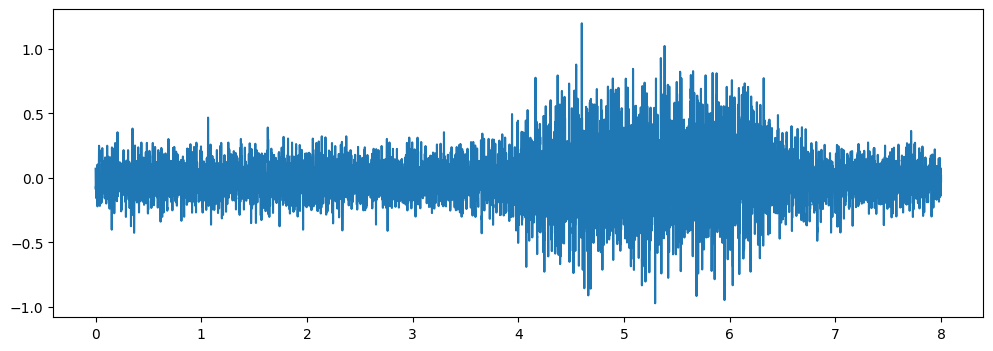

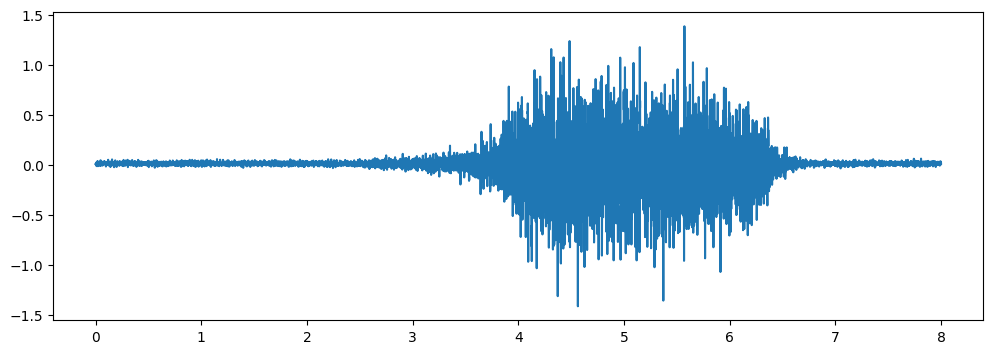

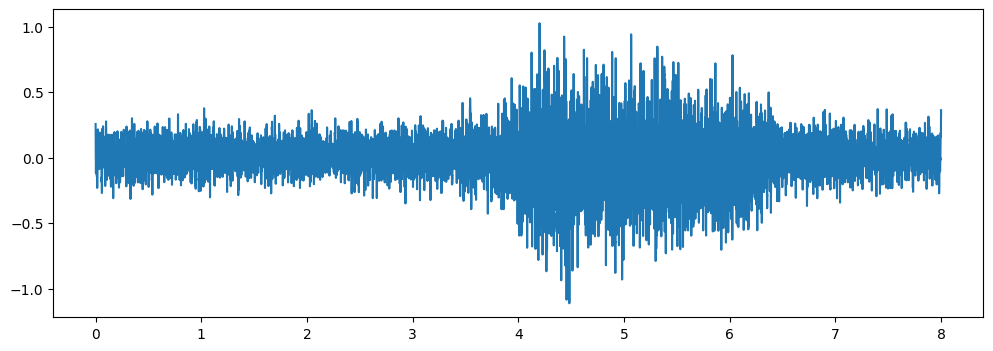

In [61]:
epoch = filtered_data.reshape(30, 16000, 3).mean(axis=0)
time = np.arange(epoch.shape[0]) / 2000
for ch in range(3):
    plt.figure(figsize=(12, 4))

    plt.plot(time, epoch[:, ch])
    

In [7]:
EMG_ins = EMG_preprocessing(fs = EMG_FREQ,
                            bandpass_lowcut = EMG_LOWCUT,
                            bandpass_highcut = EMG_HIGHCUT,
                            num_epochs = NUM_EPOCHS,
                            trial_period = TRIAL_PERIOD,
                            trim_period = TRIM_PERIOD)

EMG_index, EMG_index_epoch, EMG_index_epoch_mean, total_epochs = load_ins.load_datasets_EMG(
    path_to_data_files = EMG_index_files,
    preprocessing_func = EMG_ins.preprocessing_routine
)


RMS_index, RMS_index_epoch, RMS_index_epoch_mean, _ = load_ins.load_datasets_EMG(
    path_to_data_files = EMG_index_files,
    preprocessing_func = EMG_ins.preprocessing_routine_rms,
    sample_window = RMS_SAMPLING_WINDOW,
    window_stepsize = RMS_WINDOW_STEPSIZE
)

EMG_thumb, EMG_thumb_epoch, EMG_thumb_epoch_mean, _ = load_ins.load_datasets_EMG(
    path_to_data_files = EMG_thumb_files,
    preprocessing_func = EMG_ins.preprocessing_routine
)


RMS_thumb, RMS_thumb_epoch, RMS_thumb_epoch_mean, _ = load_ins.load_datasets_EMG(
    path_to_data_files = EMG_thumb_files,
    preprocessing_func = EMG_ins.preprocessing_routine_rms,
    sample_window = RMS_SAMPLING_WINDOW,
    window_stepsize = RMS_WINDOW_STEPSIZE
)


--------------------------
Process to obtain EMG data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Total Time 240 s
Real fs: 2000.0 Hz
Target len: 480000
EMG original len: 480000


--------------------------
Process to obtain EMG data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Total Time 240 s
Real fs: 2000.0 Hz
Target len: 480000
EMG original len: 480000


--------------------------
Process to obtain EMG data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Total Time 240 s
Real fs: 2000.0 Hz
Target len: 480000
EMG original len: 480000

Reshaped data shape: (1440000, 3)
Samples per epoch: 16000
Epoched data shape: (90, 16000, 3)
Mean epoch data shape: (16000, 3)

--------------------------
Process to obtain RMS data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Did resample from 9597 to 960

## EMG Section

### Normalization functions

In [ ]:
def MVC_EMG(json_filepath, EMG_raw):
    with open(fr'data\{json_filepath}') as f:
        calib_read = json.load(f)

    calib_dist = {}
    EMG_calib = []

    
    for k, (ch, value) in enumerate(calib_read.items()):
        ref = value['baseline_noise']
        mvc = value['MVC']
        print(f'baseline: {ref} \n mvc: {mvc}')
        
    
        calib_dist[ch] = {
            'ref' : ref,
            'mvc' : mvc
        }

        #print(f"{ch}: baseline={ref}, mvc={mvc}")
        
        if isinstance(EMG_raw, pd.DataFrame):
            normalized = ((EMG_raw.values[:, k] - ref) / (mvc - ref)) * 100
            EMG_calib.append(normalized)
            
        else:
            normalized = (EMG_raw[:, k] - ref) / (mvc - ref) * 100
            EMG_calib.append(normalized)
        
    EMG_calib = np.array(EMG_calib).T

    return EMG_calib

## Plot EMG

In [9]:
def mm_to_inches(mm):
    return mm / 25.4

def plot_emg_mean_epoch_single_channels(emg_epoch_mean, rms_epoch_mean, ch1 = 0, ch2 = 1):

    fig, axs = plt.subplots(
    1, 2,
    figsize=(mm_to_inches(162), mm_to_inches(70)),      # Before 162, 60
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )
    #print('Channel Name :', EMG_CH_NAMES[emg_ch], 'and', EMG_CH_NAMES[rms_ch])

    emg1 = np.array(emg_epoch_mean[:, ch1])
    rms1 = np.array(rms_epoch_mean[:, ch1])

    emg2 = np.array(emg_epoch_mean[:, ch2])
    rms2 = np.array(rms_epoch_mean[:, ch2])

    time = np.arange(emg1.shape[0]) / EMG_FREQ
    RMS_window_size = int(0.1 * EMG_FREQ)  # 100 ms
    win_time = (np.arange(rms1.shape[0]) * (RMS_window_size/4) + RMS_window_size/4) / EMG_FREQ

    axs[0].plot(time, emg1, color='royalblue', linewidth=1.0, label = 'Index finger')
    axs[0].plot(win_time, rms1, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    axs[0].set_xlim([0, 9])
    axs[0].set_ylim([-2, 2])
    axs[0].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Standardized EMG (a.u)')
    axs[0].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].grid(True, alpha=0.3)
    axs[0].legend(loc = 'lower left')

    axs[0].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[0].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)

    axs[1].plot(time, emg2, color='royalblue', linewidth=1.0, label='Thumb')
    axs[1].plot(win_time, rms2, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    axs[1].set_xlim([0, 9])
    axs[1].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[1].set_xlabel('Time (s)')
    axs[1].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].grid(True, alpha=0.3)
    axs[1].legend(loc = 'lower left')

    axs[1].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[1].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    
    #plt.savefig(fr'images\Nicklas_wrist_EMG\Mean_EEG_epoch_{key1}_ch{ch1}_and_{key2}_ch{ch2}_report.pdf')

vis_EMG_ins = visualize_EMG(fs = EMG_FREQ,
                            rms_sampling_window = RMS_SAMPLING_WINDOW,
                            rms_windows_stepsize = RMS_WINDOW_STEPSIZE,
                            which_finger = 'unsued',
                            num_epochs = NUM_EPOCHS,
                            total_epochs = total_epochs,
                            trial_period = TRIAL_PERIOD)

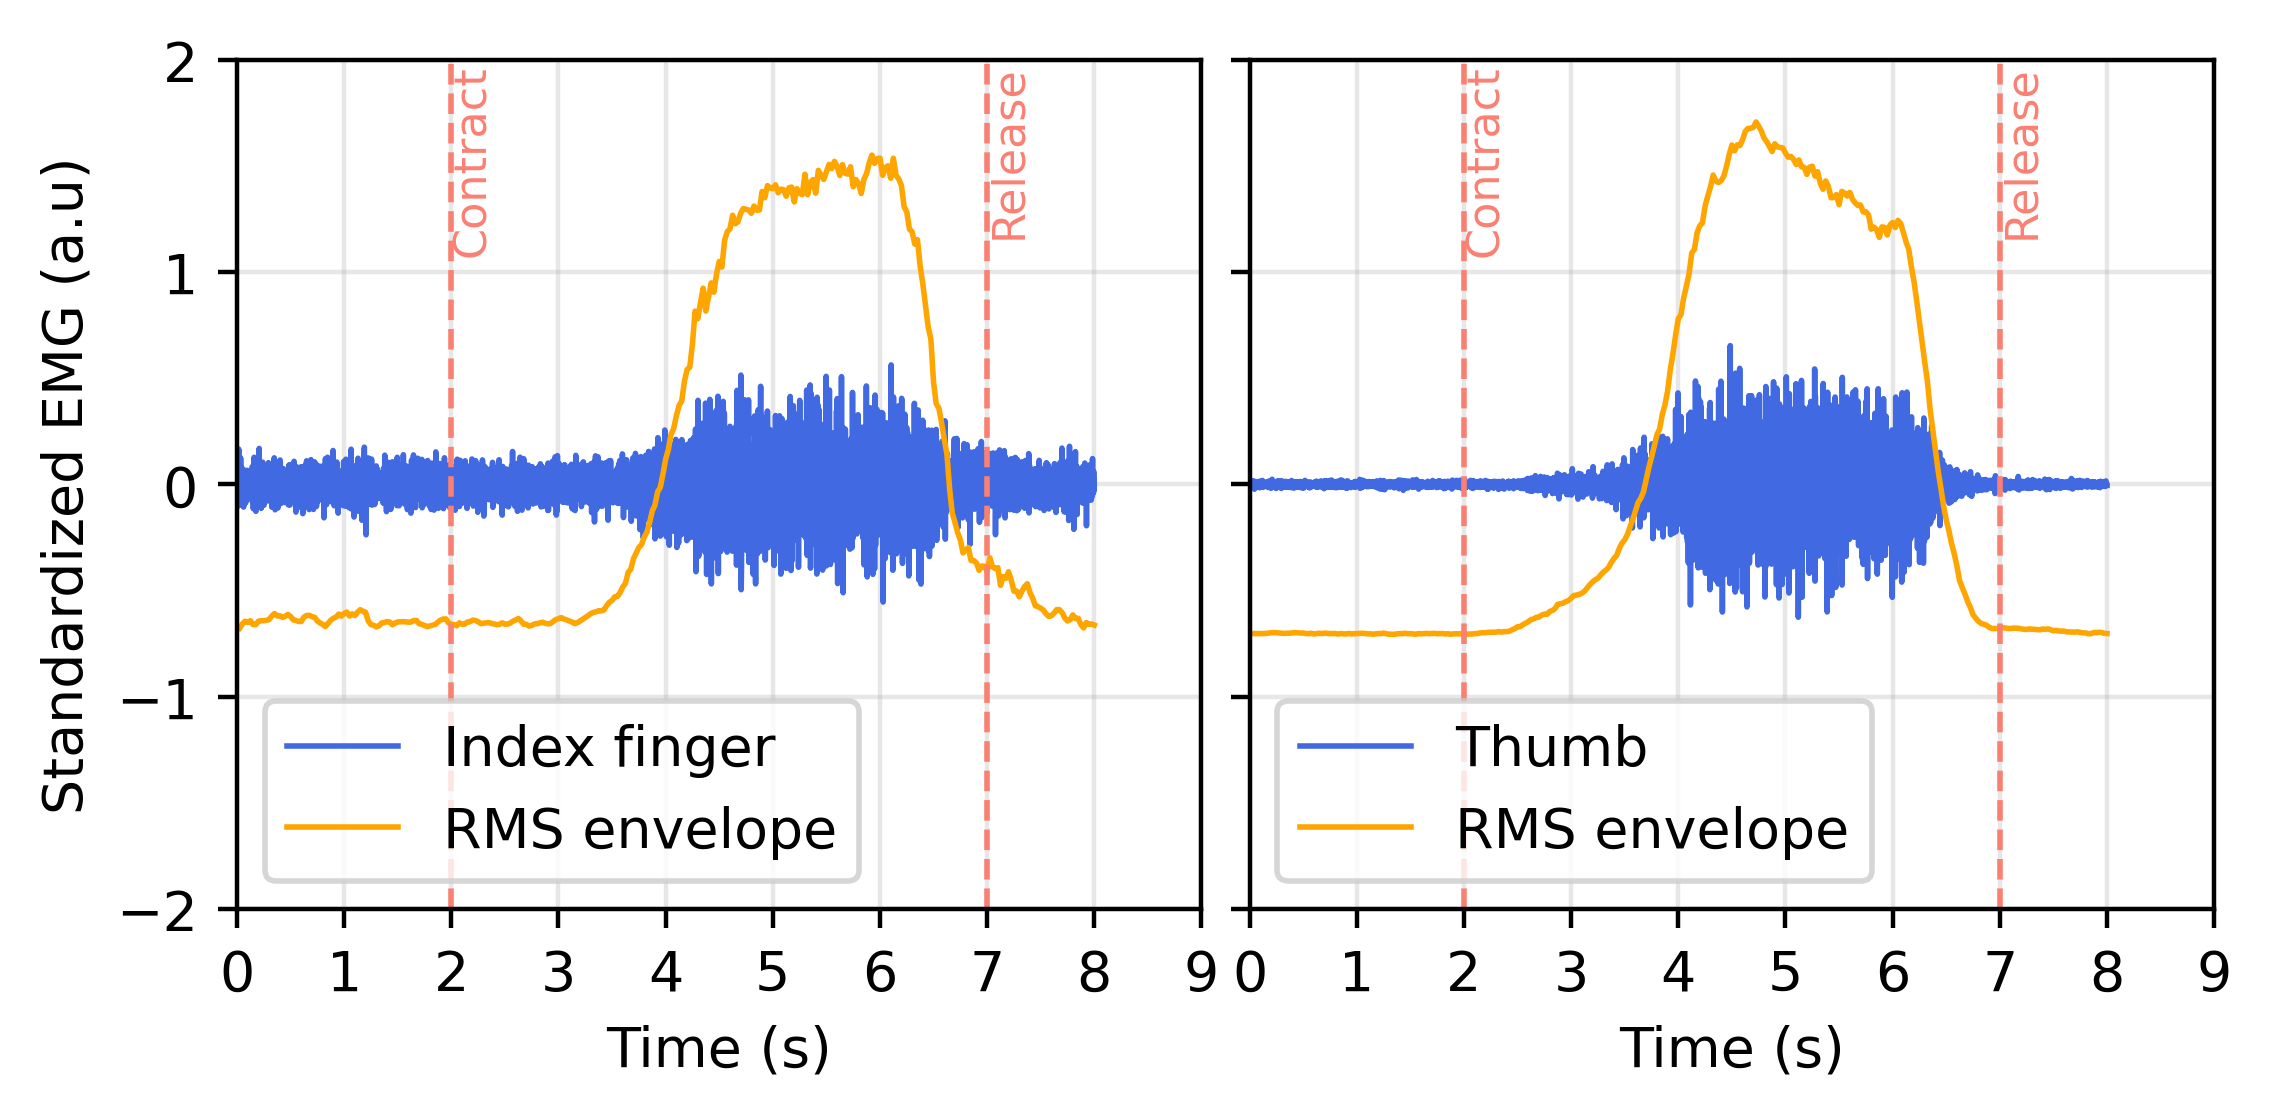

In [10]:
plot_emg_mean_epoch_single_channels(EMG_index_epoch_mean, RMS_index_epoch_mean, ch1 = 0, ch2 = 1)

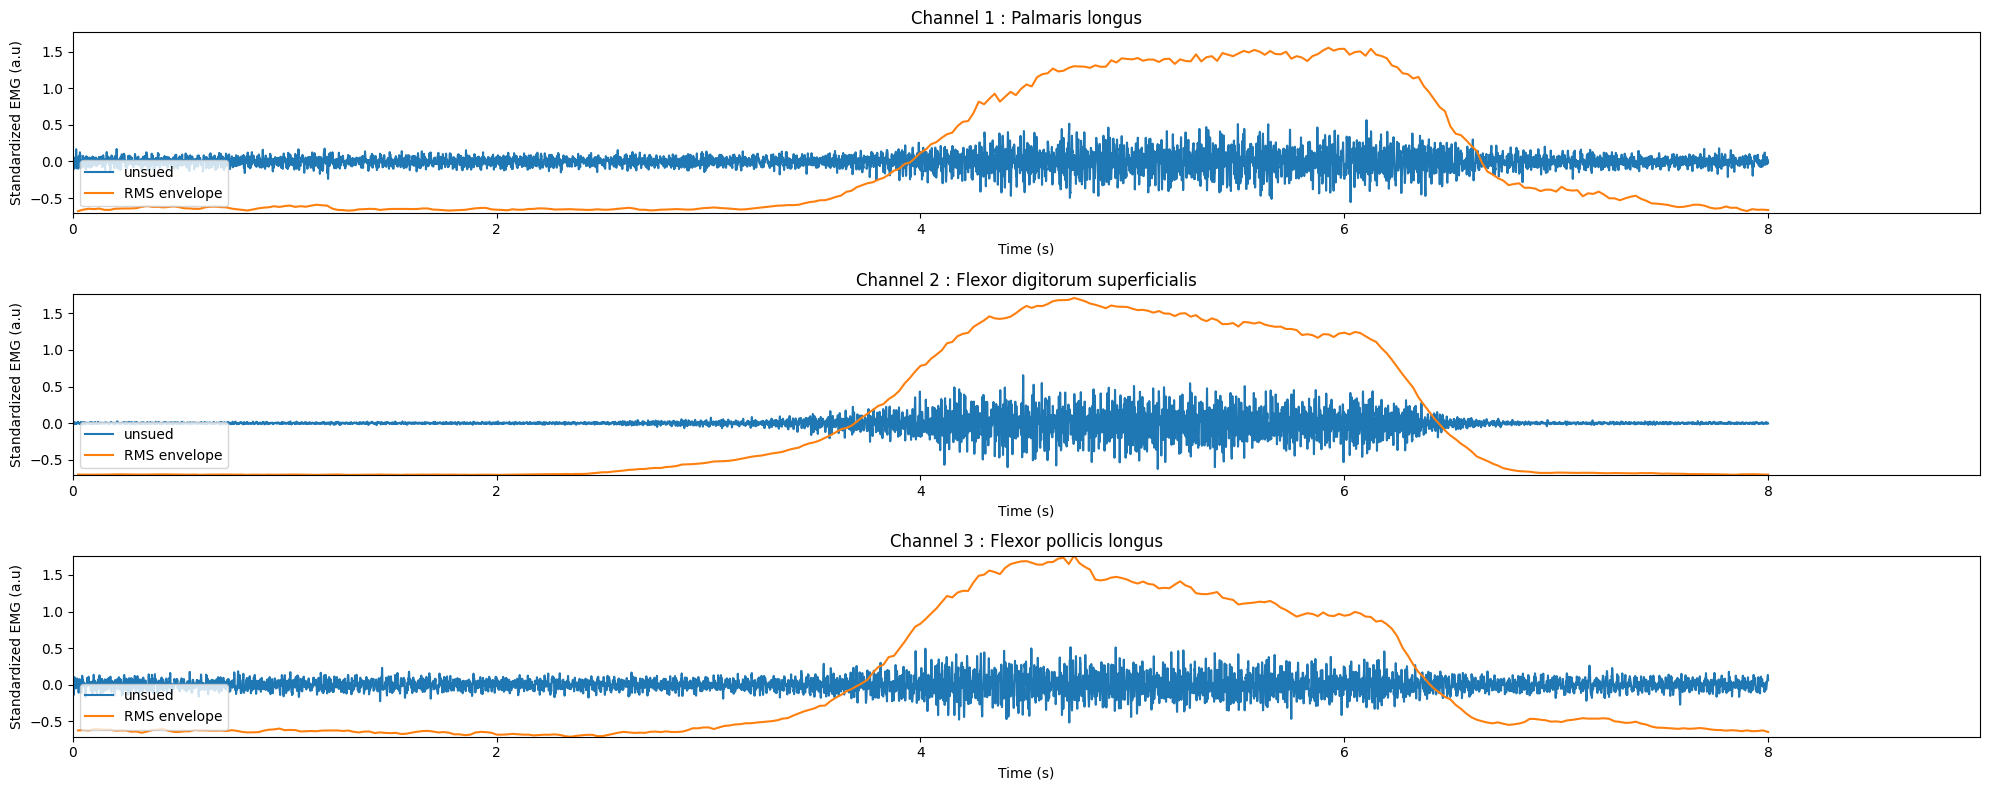

In [11]:
vis_EMG_ins.plot_rms_across_channels(EMG_index_epoch_mean, RMS_index_epoch_mean, None, 0)

## Box plot

In [29]:
def box_plot_across_channels(epoch_data, range_of_interst = 0):
    
    fingers = list(epoch_data.keys())
    n_ch = epoch_data[fingers[0]].shape[2]

    group_spacing = 1.2      # spacing between channels inside a finger-group
    finger_spacing = n_ch + 1 # spacing between finger groups

    if isinstance(range_of_interst, int):
        range_of_interst = np.arange(0, epoch_data[fingers[0]].shape[1])
        print('enter')

    # colors = [
    #     'royalblue',   # thumb
    #     'darkorange',  # index
    #     'forestgreen', # middle
    #     'firebrick',   # ring
    #     'purple',      # little
    #     'saddlebrown'  # palm
    # ]
    channel_colors = [
        'royalblue',   # ch1
        'darkorange',  # ch2
        'forestgreen', # ch3
    ]
    flierprops=dict(
        marker='*',
        markersize=0.5,
        markerfacecolor='black',
        markeredgecolor='black',
        alpha=0.6
    )

    positions = []
    labels = []
    all_box_data = []

    #plt.figure(figsize=(mm_to_inches(162/2), mm_to_inches(60)))
    fig, axs = plt.subplots(
    1, 2,
    figsize=(mm_to_inches(162), mm_to_inches(60)),      # Before 162, 60
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )

    for f_idx, finger in enumerate(fingers):

        # data shape = (epochs, samples, channels)
        n_epo, n_sam, n_ch = epoch_data[finger][:, range_of_interst, :].shape

        # flatten epochs + samples
        EMG_flat = epoch_data[finger][:, range_of_interst, :].reshape(n_epo*n_sam, n_ch)

        for ch in range(n_ch):            
            all_box_data.append(EMG_flat[:, ch])

            # compute x-position for this box
            pos = f_idx * finger_spacing + ch * group_spacing
            positions.append(pos)

            labels.append(f"{finger.capitalize()}  ch{ch+1}")

   # ---- Draw boxplot
    bp = axs[0].boxplot(
        all_box_data,
        positions=positions,
        widths=0.6,
        patch_artist=True,
        showfliers=False,
        flierprops = flierprops,
        medianprops=dict(color='black', linewidth=1.6),
        boxprops=dict(linewidth=1.0),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0)
    )

    # ---- Apply consistent channel colors
    for i, box in enumerate(bp['boxes']):
        ch = i % n_ch
        box.set_facecolor(channel_colors[ch])
        box.set_alpha(0.85)

        # ---- Aesthetics
    axs[0].set_xticks(positions, labels, rotation=15, ha='right')
    axs[0].set_ylabel("RMS EMG amplitude")
    #axs[0].set_ylim([-2, 2])

    axs[0].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    
    #plt.savefig(r'images\Nicklas_wrist_EMG\boxplot_RMS_across_ch_and_class.pdf')

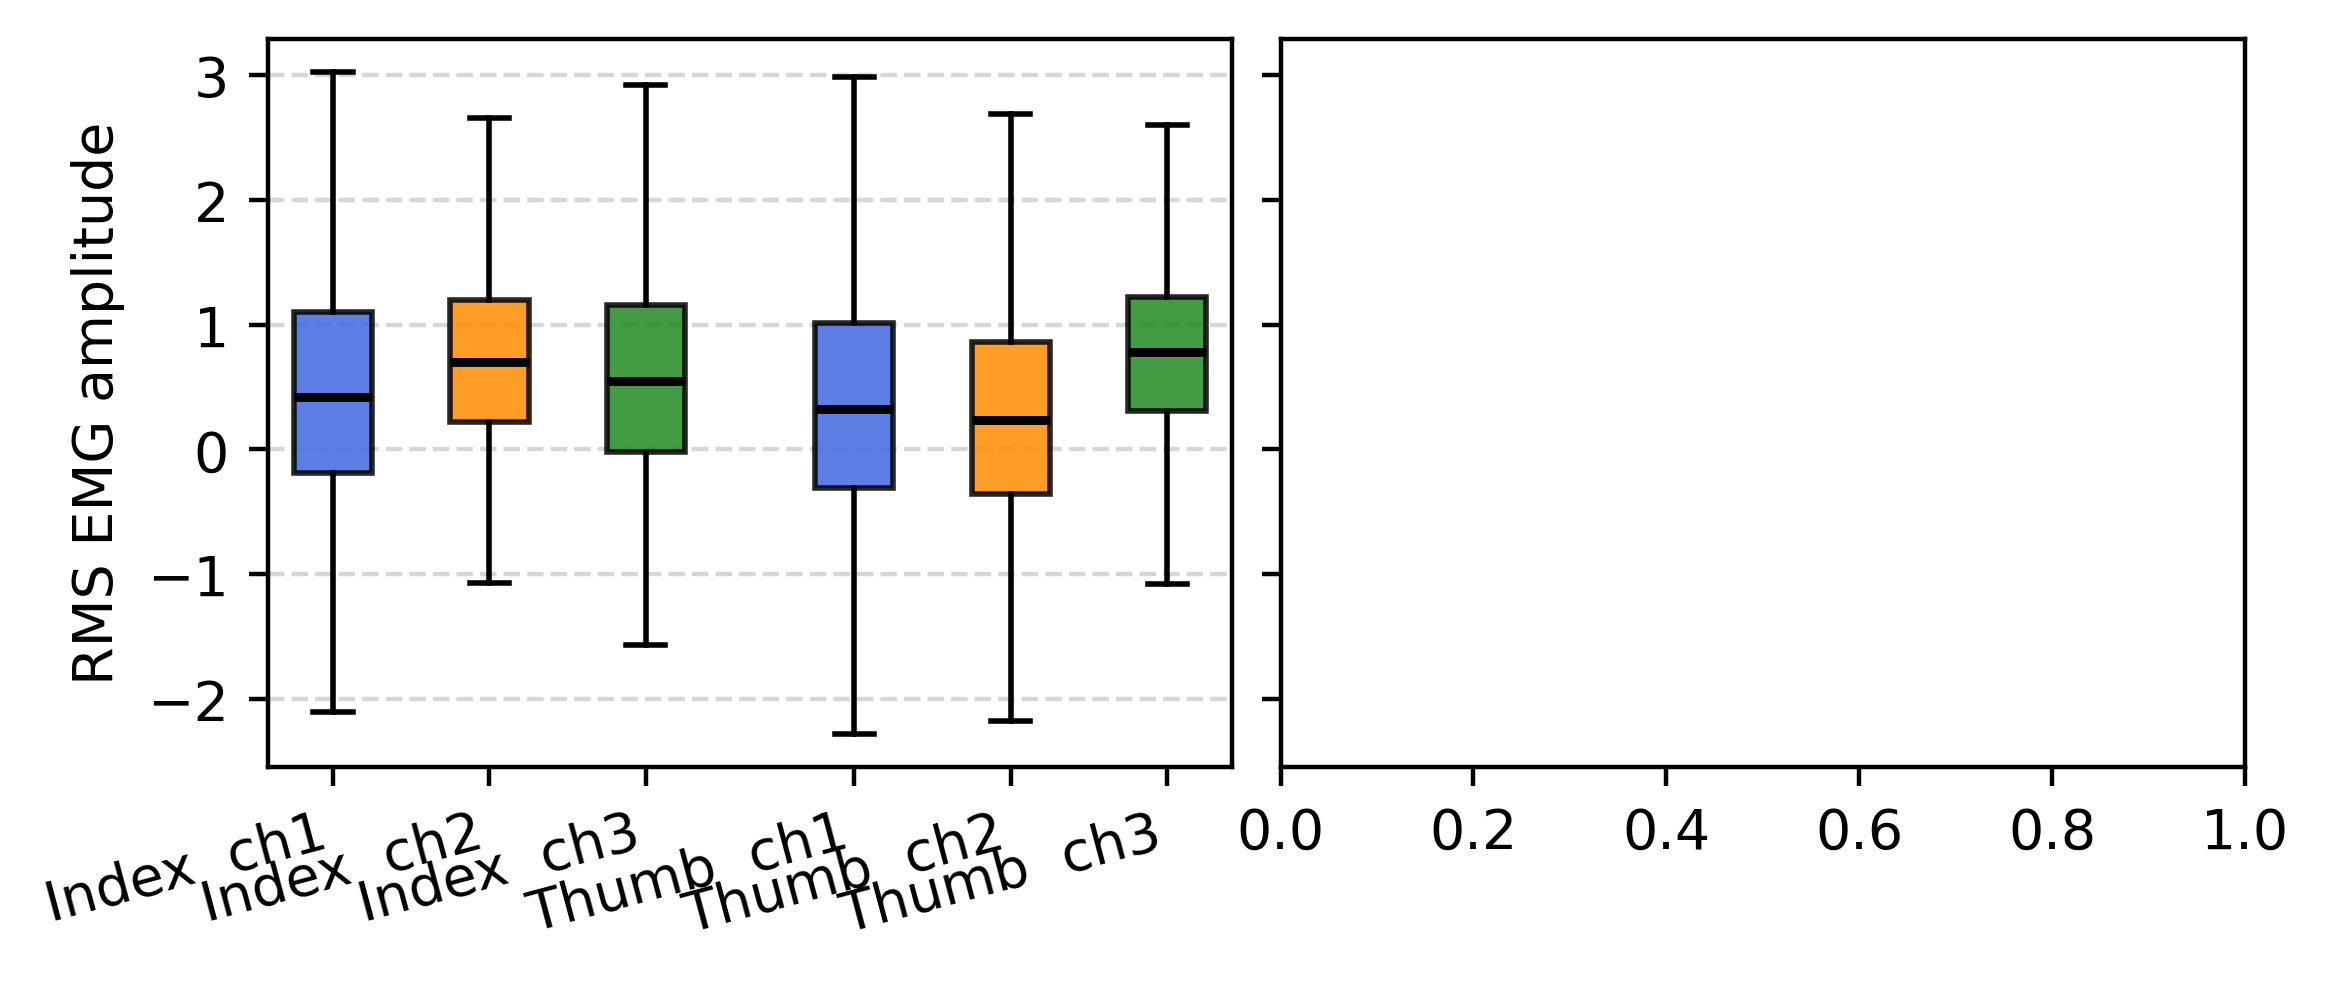

In [30]:
RMS_dict = {}

RMS_dict['index'] = RMS_index_epoch
RMS_dict['thumb'] = RMS_thumb_epoch

ONE_SEC_RANGE = RMS_index_epoch.shape[1] // TRIAL_PERIOD
CON_RANGE = np.arange(2*ONE_SEC_RANGE, 6*ONE_SEC_RANGE)

box_plot_across_channels(RMS_dict, CON_RANGE)


## EEG Section

### Functions

In [33]:
from scipy.signal import resample

class pre():
    def __init__(self,
                 fs = 125,
                 bandpass_lowcut : int = 8,
                 bandpass_highcut : int = 30,
                 trial_period : int = 9,
                 trim_period : int = 3):
        
        self.fs = fs
        self.lowcut = bandpass_lowcut
        self.highcut = bandpass_highcut
        self.trial_period = trial_period
        self.trim_period = trim_period
        self.expected_num_epochs = 30

    def trim_trial_periods(self,
                            EEG_bandpass : np.ndarray,
                            all_markers: np.ndarray,
                            markers_idx: np.ndarray,
                            extract_event : str = 'ALL',
                            trial_period = 0) -> tuple[np.ndarray, int]:
            """
            Trims the trial periods from the markers array.

            Parameters
            ----------
            EEG_bandpass : np.ndarray 
                Input of EEG data bandpass filtered
            all_markers : np.ndarray 
                Input of all markers array, including zero values
            markers_idx : np.ndarray
                Indices of non-zero markers. Can be extracted using np.nonzero()[0]
            extract_event : str
                Choise which segment of data to extract (For example: 'ALL', 'CONTRACT', 'RELEASE', 'REST')

            Returns
            ----------
            :return: List of trimmed segments
            :return: Int of the total amount of epochs for one experiment
            """
            TRIAL_PERIOD = trial_period                 # NOTE : Temporaly solution
            if extract_event == 'ALL':
                START_TRIAL_MARKER = 10
                END_TRIAL_MARKER = {10, 201}
                # TRIAL_PERIOD = 8            # 8         - 3sec period : 9
            elif extract_event == 'REST':
                START_TRIAL_MARKER = 10
                END_TRIAL_MARKER = {20, 201}
                # TRIAL_PERIOD = 2                        # 3
            elif extract_event == 'CONTRACT':
                START_TRIAL_MARKER = 20
                END_TRIAL_MARKER = {30, 201}
                # TRIAL_PERIOD = 4            # 3
            elif extract_event == 'RELEASE':
                START_TRIAL_MARKER = 30
                END_TRIAL_MARKER = {10, 201}
                # TRIAL_PERIOD = 2            # 3
            else:
                raise ValueError(f'{extract_event} is not valid event type')

            START_TRIM_MARKER = 101
            END_TRIM_MARKER = 102

            enter_trial = False             # Controls when to enter a new trial period
            enter_trim = False              # Controls when to enter a new trim period
            period_extrated = False         # Controls when the boundaries of an entire trial is selected
            num_epochs = 0                  # Increment each time a trial is appended
            st = 0                          # Start boundary index
            ed = 0                          # End boundary index
            data = EEG_bandpass.copy()      # Data
            resampled_data = []             # Resampled data to fit with desired frequency

            # Loop over non-zero indices where markers are present
            for i in range(len(markers_idx)):
                
                # Get the actual index in the markers array plus the next index
                mark_idx = markers_idx[i]
                mark_idx_next = markers_idx[i+1] if i + 1 < len(markers_idx) else None
                
                # Prevent iteration to go out of bounds. RELEASE require END_MARKER to trim the last trial
                if mark_idx_next is None and extract_event != 'RELEASE':
                    continue

                # Enter only at the start of the first trim period
                elif all_markers[mark_idx] == START_TRIM_MARKER and not enter_trim:
                    st = mark_idx
                    enter_trim = True
                
                # Enter only in the end of the first trim period
                elif all_markers[mark_idx] == END_TRIM_MARKER and enter_trim:
                    ed = mark_idx
                    period_extrated = True
                
                # Enter only at the start of each trial period
                elif all_markers[mark_idx] == START_TRIAL_MARKER and not enter_trial:
                    st = mark_idx
                    enter_trial = True

                # Enter only at the end of each trial period when the START and END marker is different.
                elif all_markers[mark_idx] in END_TRIAL_MARKER and enter_trial:
                    ed = mark_idx - 1
                    period_extrated = True
                
                # Enter only in the end of each trial period, if START and END marker belong to the same mark
                elif all_markers[mark_idx_next] in END_TRIAL_MARKER and enter_trial and START_TRIAL_MARKER in END_TRIAL_MARKER:
                    ed = mark_idx_next - 1
                    period_extrated = True
                    
                if period_extrated:
                    period_extrated = False
                    
                    if enter_trim:
                        trim_data = data[st:ed, :]
                        n_samples = trim_data.shape[0]
                        real_fs = n_samples / TRIAL_PERIOD
                        target_len = int(np.round(n_samples * (self.fs / real_fs)))

                        enter_trim = False
                        #print(f'Trial from {st} to {ed}, len: {ed - st}')
                        #print(f'Time period {trim_period}\n Real fs: {real_fs} Hz\n Target len: {target_len}\n Original len: {n_samples}')
                        
                    elif enter_trial:
                        trim_data = data[st:ed, :]
                        n_samples = trim_data.shape[0]
                        real_fs = n_samples / TRIAL_PERIOD
                        target_len = int(np.round(n_samples * (self.fs / real_fs)))

                        EEG_resampled = resample(trim_data, target_len, axis=0)
                        resampled_data.append(EEG_resampled)                  
                        
                        enter_trial = False
                        num_epochs += 1             
                        #print(f'Trial from {st} to {ed}, len: {ed - st}')
                        #print(f'Time period {trial_period}\n Real fs: {real_fs} Hz\n Target len: {target_len}\n Original len: {n_samples}')           
            
            return np.concatenate(resampled_data, axis=0), num_epochs
        
    def preprocessing_routine(self,
                            raw_eeg : np.ndarray) -> tuple[np.ndarray, int]:
        '''
        Performs the full preprocessing routine:
        1) Notch + Bandpass filter
        2) Resample + z-score standardization + Secmentation into epochs

        Parameters
        ----------
        raw_eeg : np.ndarray
            This holds keys for a specfic class (finger). NOTE - If raw_eeg is a list, it will be converted to a dict with key 'single_class'. 2D array - Dim(samples, channels)
        bandpass_lowcut : int
            Lowpass frequency
        bandpass_highcut : int
            Highpass frequency
        all_markers : list
            A log of all marker data including zero
        extract_event : str
            Choise which segment of data to extract (For example: 'ALL', 'CONTRACT', 'RELEASE', 'REST')
        
        Return
        ------
        :return: np.ndarray of normalized EEG data
        :return: Int of the total amount of epochs for one experiment
        '''

        # ---------------------------#
        # 1) NOTCH + BANDPASS FILTER #
        # ---------------------------#
        EEG_filter_ins = Filtering(fs = self.fs)
        
        EEG_notch = EEG_filter_ins.notch(raw_eeg, cutoff=50, Q=30)
        EEG_bandpass, _ = EEG_filter_ins.butter_bandpass(EEG_notch, lowcut = self.lowcut, highcut = self.highcut, order=4)

        #===============================#
        # 2) Calculate number of epochs #
        #===============================#
        num_trim_samples = self.fs * self.trim_period * 2                   # Total samples from trim period. WHY *2 : Trim egde on both sides
        num_valid_samples = EEG_bandpass.shape[0] - num_trim_samples        # Total samples for experimental period
        cal_num_epochs = num_valid_samples / (self.fs * self.trial_period)  # Divide out total samples in sections of trial periods -> Results in number of epochs
        if cal_num_epochs != self.expected_num_epochs:                      # Inform if epochs is differnet from usual amount. Can happen if bad trials is removed.
            print(f'OBSERVATION - NUM OF EPOCH ({cal_num_epochs}) IS DIFFERNET FROM USUAL {self.expected_num_epochs}')
        
        cal_num_epochs = int(np.round(cal_num_epochs))


        # --------#
        # 3) TRIM #
        # --------#
        trim_idx_102 = self.fs * self.trim_period
        trim_idx_201 = (self.fs * self.trial_period * cal_num_epochs) + trim_idx_102        # WHY instead of data[trim : -trim] -> Inconsistency in protocol causes the last batch of data not be included -> Rare but can happen
        EEG_trim = EEG_bandpass[trim_idx_102 : trim_idx_201, :]
        print(f"Original shape {EEG_bandpass.shape}\n"
              f"Trim 102 idx {trim_idx_102}\n"
              f"Trim 201 idx {trim_idx_201}\n"
              f'EEG_trim shape: {EEG_trim.shape}\n')
        

        #EEG_car = EEG_trim - np.mean(EEG_trim, axis = 1, keepdims = True)       # (S, C)

        # power = np.abs(EEG_car) ** 2
        # from scipy.signal import hilbert
        # power = np.abs(hilbert(EEG_car, axis=0)) ** 2

        ## TRY TO REMOVE NOISE IN THE REST PERIOD
        ## SEE HOW THE POWER CHANGES

        # --------------------------------------------------
        # 3) Z-SCORE STANDARDIZATION
        # --------------------------------------------------
        #EEG_norm = EEG_filter_ins.zscore(EEG_car, mode = 'within_ch')
        
        return EEG_trim, cal_num_epochs

### Load datasets

In [97]:
base_dir = Path().resolve() / 'data'

load_ins = load_datasets(base_dir = base_dir)

EEG_ins = pre(fs = 125,
              bandpass_lowcut = 8,
              bandpass_highcut = 30,
              trial_period = 9,
              trim_period = 3)

EEG_index_files = load_ins.find_flex_files(
        subjects = 'subject_0_closedEyes',
        modality = 'EEG',
        fingers = 'index',
        prefix = 'flex'
    )

EEG_thumb_files = load_ins.find_flex_files(
        subjects = 'subject_0_closedEyes',
        modality = 'EEG',
        fingers = 'thumb',
        prefix = 'flex'
    )

marker_pro = load_ins.find_flex_files(
        subjects = 'subject_0_closedEyes',
        modality = 'Markers',
        fingers = 'index',
        prefix = 'flex'
    )

total_epochs = 0
eeg_num_ch = 16
all_data = []


for data_file in EEG_index_files:
    print(data_file)

    EEG_df = pd.read_csv(data_file)
    EEG_raw = EEG_df.iloc[:, 1:17].to_numpy()
    EEG_marker_log = EEG_df.iloc[:, -1].to_numpy()

    EEG_filt, num_epochs = EEG_ins.preprocessing_routine(raw_eeg = EEG_raw)
    
    all_data.append(EEG_filt)
    total_epochs += num_epochs
    break                       # Only load one data

EEG = np.concatenate(all_data, axis = 0)
print(f"Reshaped data shape: {EEG.shape}")

EEG_samples_per_epoch = EEG.shape[0] // total_epochs      
print(f"Samples per epoch: {EEG_samples_per_epoch}")

EEG_epoch = EEG.reshape(total_epochs, EEG_samples_per_epoch, eeg_num_ch)

EEG_epoch_mean = EEG_epoch.mean(axis=0)
print(f"Epoched data shape: {EEG_epoch.shape}")
print(f"Mean epoch data shape: {EEG_epoch_mean.shape}")

marker = load_ins.load_datasets_marker(marker_pro)[0].to_numpy()

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0_closedEyes\EEG\flex_index_finger_2026-02-05 14-19-21.csv
OBSERVATION - NUM OF EPOCH (30.061333333333334) IS DIFFERNET FROM USUAL 30
Original shape (34569, 16)
Trim 102 idx 375
Trim 201 idx 34125
EEG_trim shape: (33750, 16)

Reshaped data shape: (33750, 16)
Samples per epoch: 1125
Epoched data shape: (30, 1125, 16)
Mean epoch data shape: (1125, 16)
3


In [135]:
# See time period difference between pro and EEG markers
st_val = 0
st_flag = False
end_val = 0
sum = 0
for i in range(len(EEG_marker_idx)):
    if EEG_marker_log[EEG_marker_idx[i]] == 10.0 or EEG_marker_log[EEG_marker_idx[i]] == 201:
        if not st_flag:
            st_val = time[EEG_marker_idx[i]]
            st_flag = True
            continue
        
        if st_flag:
            end_val = time[EEG_marker_idx[i]]
            print(end_val - st_val)
            sum += end_val - st_val
            st_val = time[EEG_marker_idx[i]]

print('SUM', sum)

print('\nLOOK AT PROTOCOL MARKERS')
st_val = 0
st_flag = False
end_val = 0
sum = 0
for i in range(len(pro_marker)):

    if pro_marker[i] == 10.0 or pro_marker[i] == 201:
        if not st_flag:
            st_val = pro_time[i]
            st_flag = True
            continue
        
        if st_flag:
            end_val = pro_time[i]
            print(end_val - st_val)
            sum += end_val - st_val
            st_val = pro_time[i]

print('SUM', sum)
        

8.651313781738281
9.13242506980896
9.132844924926758
8.652396202087402
9.131313800811768
9.133009195327759
9.131736993789673
8.65294885635376
9.131448030471802
9.133162021636963
9.132513999938965
8.651917934417725
9.132568120956421
9.132497072219849
8.65257477760315
9.13158917427063
9.133107900619507
9.131459951400757
8.652934074401855
9.132235050201416
9.132382869720459
9.133690118789673
8.650040864944458
9.133076190948486
9.131692886352539
8.652043104171753
9.132438898086548
9.133625030517578
9.132220983505249
8.651685953140259
SUM 269.6488938331604

LOOK AT PROTOCOL MARKERS
9.0002611
9.000253400000002
9.000268899999998
9.001958599999998
9.0002949
9.0002688
9.000253199999996
9.000257500000004
9.000247799999997
9.000390500000009
9.000321099999994
9.000246000000004
9.00056339999999
9.000258800000012
9.000304599999993
9.000280400000008
9.000300600000003
9.000246799999985
9.000279599999999
9.000269700000018
9.000245499999977
9.0003198
9.000323100000003
9.00024620000002
9.00028119999999
9

In [36]:
def plot_insert_markers(time_array, selected_time, marker_nonzero):
    color_list = {
    10 : 'salmon',
    20 : 'green',
    30 : 'yellow'
    }
    for i, mark in enumerate(marker_nonzero):
        t = time_array[i]
        if t > selected_time[-1]:
            break
        elif t < selected_time[0]:
            continue

        if mark in color_list.keys():
            plt.axvline(x=t, color=color_list[mark], linestyle='--', alpha=0.5)
            plt.text(t, plt.ylim()[1]*0.9, f'{mark}',
                    rotation=90, color='salmon', ha='left', va='top', fontsize=10
                )

def compute_ICA(rest_data, all_data):
    import mne
    _, n_channels = all_data.shape
    ch_names = [f"ch{i}" for i in range(n_channels)]
    ch_types = ["eeg"] * n_channels
    sfreq = 125

    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
    raw_rest = mne.io.RawArray(rest_data.T, info)
    raw_data = mne.io.RawArray(all_data.T, info)

    ica = mne.preprocessing.ICA(
    n_components=4,   # keep 99% variance OR use a fixed number like 15
    method='fastica',
    max_iter = 1000,
    random_state=97
    )

    #reject = dict(eeg = 80)
    ica.fit(raw_rest, reject=None)

    ica.plot_sources(inst = raw_rest, picks = None, start = 0, stop = 70, theme = 'dark')

    ica.exclude = [0]
    raw_clean = ica.apply(raw_data.copy())

    return raw_clean.get_data().T

def trim_trial_periods(
                        EEG_bandpass : np.ndarray,
                        all_markers: np.ndarray,
                        markers_idx: np.ndarray,
                        time_array : np.ndarray,
                        extract_event : str = 'ALL') -> tuple[np.ndarray, int]:
    """
    Trims the trial periods from the markers array.

    Parameters
    ----------
    EEG_bandpass : np.ndarray 
        Input of EEG data bandpass filtered
    all_markers : np.ndarray 
        Input of all markers array, including zero values
    markers_idx : np.ndarray
        Indices of non-zero markers. Can be extracted using np.nonzero()[0]
    extract_event : str
        Choise which segment of data to extract (For example: 'ALL', 'CONTRACT', 'RELEASE', 'REST')

    Returns
    ----------
    :return: List of trimmed segments
    :return: Int of the total amount of epochs for one experiment
    """
    if extract_event == 'ALL':
        START_TRIAL_MARKER = 10
        END_TRIAL_MARKER = {10, 201}
        TRIAL_PERIOD = 9
    elif extract_event == 'REST':
        START_TRIAL_MARKER = 10
        END_TRIAL_MARKER = {20, 201}
        TRIAL_PERIOD = 3
    elif extract_event == 'CONTRACT':
        START_TRIAL_MARKER = 20
        END_TRIAL_MARKER = {30, 201}
        TRIAL_PERIOD = 3
    elif extract_event == 'RELEASE':
        START_TRIAL_MARKER = 30
        END_TRIAL_MARKER = {10, 201}
        TRIAL_PERIOD = 3
    else:
        raise ValueError(f'{extract_event} is not valid event type')

    START_TRIM_MARKER = 101
    END_TRIM_MARKER = 102

    enter_trial = False             # Controls when to enter a new trial period
    enter_trim = False              # Controls when to enter a new trim period
    period_extrated = False         # Controls when the boundaries of an entire trial is selected
    num_epochs = 0                  # Increment each time a trial is appended
    st = 0                          # Start boundary index
    ed = 0                          # End boundary index
    data = EEG_bandpass.copy()      # Data
    resampled_data = []             # Resampled data to fit with desired frequency

    variable_freq = 0
    # Loop over non-zero indices where markers are present
    for i, mark_id in enumerate(markers_idx):
        
        # Convert time at marker to index
        current_time = time_array[i]
        mark_idx = current_time * variable_freq          # Variable frequency
        
        # Enter only at the start of the first trim period
        if mark_id == START_TRIM_MARKER and not enter_trim:
            st = mark_idx
            enter_trim = True
        
        # Enter only in the end of the first trim period
        elif mark_id == END_TRIM_MARKER and enter_trim:
            ed = mark_idx
            _, freq = sub_trim(data, st, ed, enter_trim, enter_trial, variable_freq, TRIAL_PERIOD)
            enter_trim = False
        
        # Enter only at the start of each trial period
        elif mark_id == START_TRIAL_MARKER and not enter_trial:
            st = mark_idx
            enter_trial = True

            # Enter only in the end of each trial period, if START and END marker belong to the same mark
        elif (mark_id in END_TRIAL_MARKER) and enter_trial and (START_TRIAL_MARKER in END_TRIAL_MARKER):
            ed = mark_idx

            st = mark_idx

        # Enter only at the end of each trial period when the START and END marker is different.
        elif mark_id in END_TRIAL_MARKER and enter_trial:
            ed = mark_idx
            period_extrated = True

    return np.concatenate(resampled_data, axis=0), num_epochs

def sub_trim(data, st, ed, enter_trim, enter_trial, variable_freq, trial_period):     
    trim_data = data[st:ed, :]
    n_samples = trim_data.shape[0]
    
    if enter_trim:
        real_fs = n_samples / trial_period
        target_len = int(np.round(n_samples * (variable_freq / real_fs)))

        print(f'Trial from {st} to {ed}, len: {ed - st}')
        print(f'Time period {3}\n Real fs: {real_fs} Hz\n Target len: {target_len}->True: {n_samples * (variable_freq / real_fs)}\n Original len: {n_samples}')
            
    elif enter_trial:
        trim_data = data
        n_samples = trim_data.shape[0]
        real_fs = n_samples / trial_period
        target_len = int(np.round(n_samples * (variable_freq / real_fs)))

        EEG_resampled = resample(trim_data, target_len, axis=0)               
                    
        #print(f'Trial from {st} to {ed}, len: {ed - st}')
        print(f'Time period {trial_period}\n Real fs: {real_fs} Hz\n Target len: {target_len}->True: {n_samples * (variable_freq / real_fs)}\n Original len: {n_samples}')
    
    return EEG_resampled, real_fs

Creating RawArray with float64 data, n_channels=16, n_times=34569
    Range : 0 ... 34568 =      0.000 ...   276.544 secs
Ready.
Creating RawArray with float64 data, n_channels=16, n_times=34569
    Range : 0 ... 34568 =      0.000 ...   276.544 secs
Ready.
Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by number: 4 components


C:\Users\Bruger\AppData\Local\Temp\ipykernel_17064\1889538302.py:39: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw_rest, reject=None)


Fitting ICA took 1.5s.
Creating RawArray with float64 data, n_channels=4, n_times=34569
    Range : 0 ... 34568 =      0.000 ...   276.544 secs
Ready.
Using matplotlib as 2D backend.


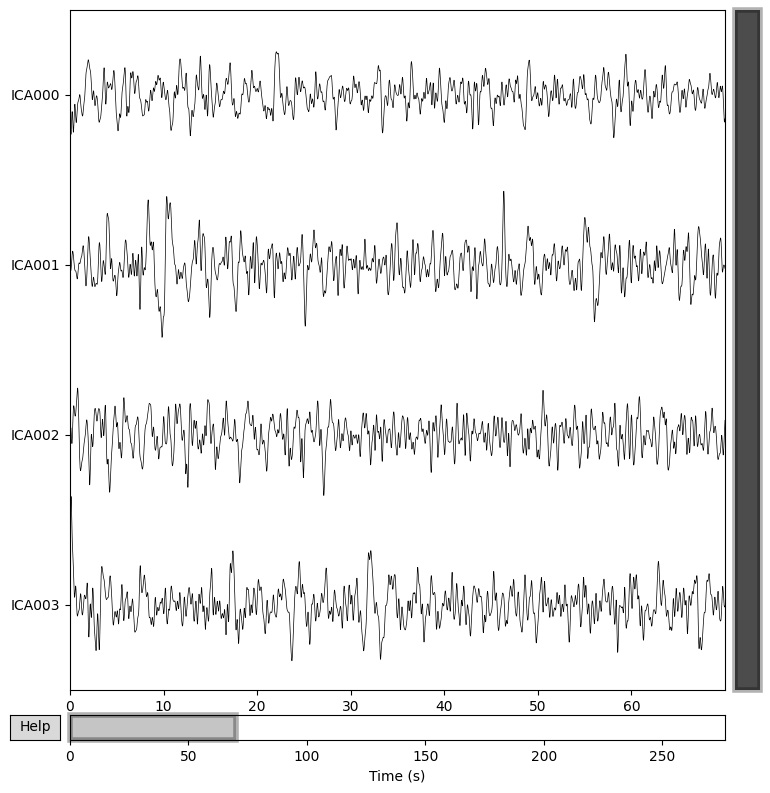

Applying ICA to Raw instance
    Transforming to ICA space (4 components)
    Zeroing out 1 ICA component
    Projecting back using 16 PCA components


In [12]:
EEG_filter_ins = Filtering(fs = 125)

EEG_notch = EEG_filter_ins.notch(EEG_raw, cutoff=50, Q=30)
EEG_bandpass, _ = EEG_filter_ins.butter_bandpass(EEG_notch, lowcut=0.3, highcut=4, order=4)

EEG_ica = compute_ICA(EEG_bandpass, EEG_bandpass)

X = EEG_ica.copy()

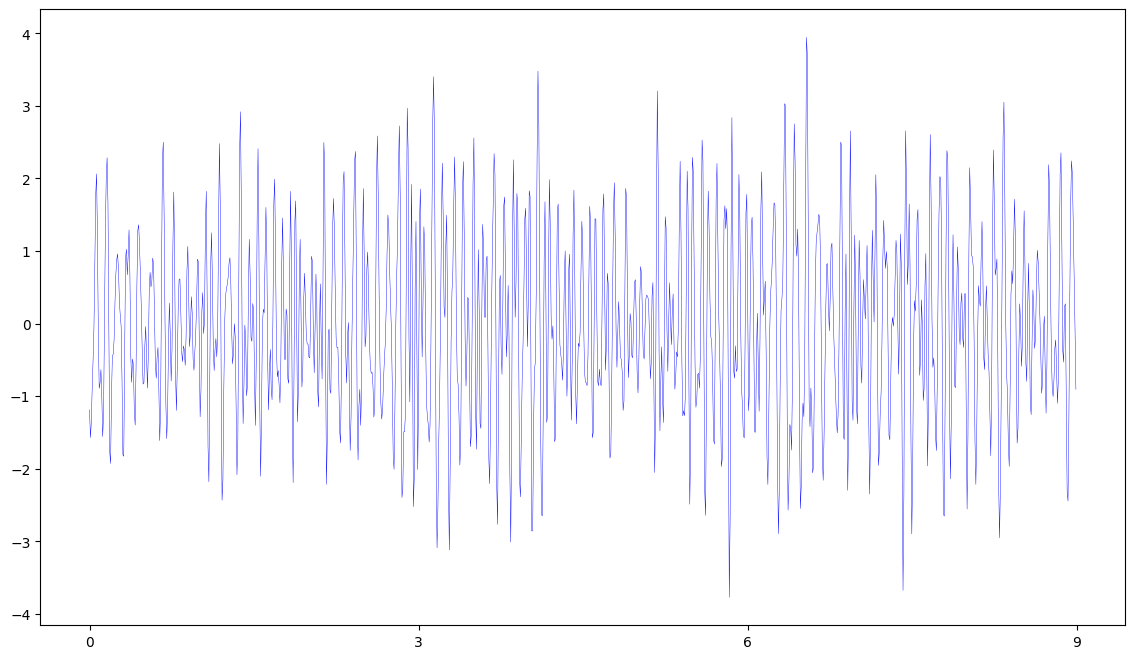

In [101]:
select_window = [0, 9]
tst = select_window[0] * 125
tend = select_window[1] * 125

# sel_time = EEG_time[tst:tend]
sel_data = EEG[tst:tend, 2]
sel_time = select_window[0] + np.arange(sel_data.shape[0]) / 125
#sel_time = EEG_time[tst:tend]

# MARKESR FROM PROTOCOL
plt.figure(figsize=(14, 8))
plt.plot(sel_time, EEG_epoch_mean[:, 5], linewidth = 0.3, c = 'b')

plot_insert_markers(marker[3:, 0], sel_time, marker[:, 1])

plt.xticks(np.arange(select_window[0], select_window[-1]+0.1, 3))
plt.show()

## ERSP computational functions

In [ ]:
def compute_mrcp(epochs_mean):
    """
    epochs: array (n_samples, n_channels)
    baseline_samples: baseline region before movement

    Returns: mrcp (channels x samples)
    """
    r0 = 0
    k = 250

    baseline = epochs_mean[r0:r0+k, :]
    R = baseline.mean(axis=0, keepdims=True)

    epochs_baselined = epochs_mean - R
    
    #mrcp = epochs_baselined.mean(axis=0)

    return epochs_baselined

def compute_ERD_ERS_pfurtscheller(epoch, fs = 125):
    """
    resampled_data: (np.Array) 
        shape (n_samples, n_channels)
    """
    eps = 1e-12
    
    r0 = fs * 0     # samples for x seconds
    k = fs * 2      # samples for x seconds

    power = epoch**2
    
    # 3) Act(j): average power across trials
    Act = np.mean(power, axis=0)
    print(f'Act.shape: {Act.shape}')

    # 4) Baseline R
    baseline = Act[r0:r0+k, :]
    R = np.mean(baseline, axis = 0)

    print(f'R value: {R}')
    
    # 5) ERD/ERS
    rts = ((Act - R) / (R + eps)) * 100

    return rts

def plot_wavelet_spectrogram(epoch_mean, freq_bands={'mu': (8, 13), 'beta': (13, 30)}, freq_bins = 75):
    
    for freq_interst in freq_bands.keys():
        erd_ers, wt_freq = compute_erd_ers_pywt(epoch_mean = epoch_mean,
                                       freq_min = freq_bands[freq_interst][0], 
                                       freq_max = freq_bands[freq_interst][1],
                                       freq_bins = freq_bins)
    
        plt.figure(figsize=(10, 5))
        extent = [0, len(erd_ers)/EEG_FREQ, freq_bands['mu'][0], freq_bands['beta'][1]]
        
        for sch in range(EEG_NUM_CH):
            X = erd_ers[:, sch]

            plt.imshow(
                [X, wt_freq],
                aspect='auto',
                origin='lower',
                extent=extent,
                cmap='turbo'
            )

    plt.colorbar(label="Power change (%)")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Baseline-corrected Wavelet Spectrogram\nChannel {EEG_CH_NAMES[sch]}")
    plt.axhline(8, color='white', linestyle='--', alpha=0.6)
    plt.axhline(13, color='white', linestyle='--', alpha=0.6)
    plt.axhline(30, color='white', linestyle='--', alpha=0.6)
    plt.show()

### TRY OUT ERD 

In [ ]:
import numpy as np
from scipy.signal import butter, sosfiltfilt, hilbert

def compute_erd(
    data,
    markers,
    fs,
    band=(8, 12),
    rest_sec=3.0,
    baseline_sec=(-3.0, 0.0)
):
    """
    epochs: (n_epochs, n_samples, n_channels)
    Epoch structure:
        0-3s   : REST
        3-6s   : MOVE
        6-9s   : RELEASE
    """
    EEG_ins = EEG_preprocessing(125)

    # 1) Bandpass
    sos = butter(4, band, btype="bandpass", fs=fs, output="sos")
    x = sosfiltfilt(sos, data, axis=0)

    marker_idx = np.nonzero(markers)[0]
    x_trim, total_epochs = EEG_ins.trim_trial_periods(x, markers, marker_idx, 'ALL', 9)
    
    
    n_samples, n_ch = x_trim.shape

    EEG_samples_per_epoch = n_samples // total_epochs      

    epoch = x_trim.reshape(total_epochs, EEG_samples_per_epoch, n_ch)

    epoch_car = epoch - epoch.mean(axis = 2, keepdims = True)

    # 2) Power
    # power = np.abs(epoch_car) ** 2
    power = np.abs(hilbert(epoch_car, axis=1)) ** 2

    print(f"Samples per epoch: {EEG_samples_per_epoch} - Without // : {n_samples / total_epochs}")
    print(f"Reshaped data shape: {power.shape}")
    print(f"Epoched data shape: {epoch.shape}")

    # 3) Onset index (movement starts after REST)
    onset_idx = int(rest_sec * fs)

    # 4) Baseline = REST
    b0 = onset_idx + int(baseline_sec[0] * fs)  # = 0
    b1 = onset_idx + int(baseline_sec[1] * fs)  # = onset_idx

    R = np.mean(power[:, b0:b1, :], axis=1, keepdims=True)

    # 5) ERD%
    erd_all = (power - R) / (R + 1e-12) * 100.0
    erd_mean = erd_all.mean(axis=0)

    return erd_mean, erd_all, epoch, epoch_car

def compute_erd_pywt(data, markers, band = (2, 32), freq_min = 8, freq_max = 12, freq_bins = 75, rest_sec = 3.0, baseline_sec = (-3.0, 0.0), fs = 125):
    import pywt
    wt_obj = "morl"
    wt_dt = 1.0/fs

    wt_freqs_interst = np.linspace(freq_min, freq_max, freq_bins)
    wt_scales = pywt.frequency2scale(wt_obj, wt_freqs_interst) / wt_dt

    EEG_ins = EEG_preprocessing(125)

    # 1) Bandpass
    sos = butter(4, band, btype="bandpass", fs=fs, output="sos")
    x = sosfiltfilt(sos, data, axis=0)

    marker_idx = np.nonzero(markers)[0]
    x_trim, total_epochs = EEG_ins.trim_trial_periods(x, markers, marker_idx, 'ALL', 9)
    
    # Make epochs
    n_samples, n_ch = x_trim.shape
    EEG_samples_per_epoch = n_samples // total_epochs      
    epoch = x_trim.reshape(total_epochs, EEG_samples_per_epoch, n_ch)
    # epoch_car = epoch - epoch.mean(axis = 2, keepdims = True)


    wt_coef, wt_freq = pywt.cwt(
        data =  epoch,              # (E, S, C)
        scales = wt_scales,         # (F)
        wavelet = wt_obj,
        method = 'conv',
        sampling_period=wt_dt,
        precision = 12,
        axis = 1
    )   # Coef: (F, E, S, C)

    # 2) Power
    power = np.abs(wt_coef) ** 2
    #power = np.abs(hilbert(epoch_car, axis=1)) ** 2

    print(f"Samples per epoch: {EEG_samples_per_epoch} - Without // : {n_samples / total_epochs}")
    print(f"Reshaped data shape: {power.shape}")
    print(f"Epoched data shape: {epoch.shape}")

    # 3) Onset index (movement starts after REST)
    onset_idx = int(rest_sec * fs)

    # 4) Baseline = REST
    b0 = onset_idx + int(baseline_sec[0] * fs)  # = 0
    b1 = onset_idx + int(baseline_sec[1] * fs)  # = onset_idx

    R = np.mean(power[:, b0:b1, :], axis=2, keepdims=True)      # (F, E, 1, C)

    # 5) ERD%  
    erd_all = (power - R) / (R + 1e-12) * 100.0                 # (F, E, S, C)
    erd_mean = erd_all.mean(axis=1)                             # (F, S, C)

    return erd_mean, erd_all, wt_freq

import numpy as np
from scipy.signal import butter, filtfilt, decimate, iirnotch
from scipy.stats import zscore, kurtosis


def common_average_reference(eeg):
    """
    EEG shape: (samples, channels)
    """
    return eeg - np.mean(eeg, axis=1, keepdims=True)


def detect_bad_channels(eeg, z_thresh=5.0):
    """
    Proxy for EEGLAB joint probability.
    Flags channels with abnormal variance.
    """
    channel_var = np.var(eeg, axis=0)
    z = zscore(channel_var)
    bad_idx = np.where(np.abs(z) > z_thresh)[0]
    print(f'bad channel idx: {bad_idx} - np.abs(z) : {np.abs(z)}')
    return bad_idx


def detect_artifact_epochs(epochs, amp_thresh=200e-6, kurt_thresh=5.0):
    """
    Detect artifact-contaminated epochs
    epochs shape: (n_epochs, n_samples, n_channels)
    """
    bad_epochs = []

    for i, ep in enumerate(epochs):
        # Amplitude threshold
        if np.any(np.abs(ep) > amp_thresh):
            bad_epochs.append(i)
            continue

        # Kurtosis across time (averaged over channels)
        k = np.mean(kurtosis(ep, axis=0, fisher=True))
        if np.abs(k) > kurt_thresh:
            bad_epochs.append(i)

    return np.array(bad_epochs)


def ofner_mrcp_preprocessing(
    eeg,
    markers,
    fs,
    band = (0.3, 3)
):
    """
    Reproduces Ofner et al., 2017 MRCP preprocessing.

    Parameters
    ----------
    eeg : np.ndarray
        Shape (samples, channels)
    fs : float
        Original sampling frequency
    movement_onsets : np.ndarray
        Sample indices of movement onset
    """

    # 1) Remove bad channels
    bad_ch = detect_bad_channels(eeg)
    eeg = np.delete(eeg, bad_ch, axis=1)

    # 2) Bandpass
    EEG_ins = EEG_preprocessing(125)
    EEG_filt_ins = Filtering(125)

    b, a = iirnotch(w0=50, Q=30, fs=fs)
    x_notch = filtfilt(b, a, eeg, axis=0)

    sos = butter(4, band, btype="bandpass", fs=fs, output="sos")
    x_filt = sosfiltfilt(sos, x_notch, axis=0)

    # 3) Epochs
    marker_idx = np.nonzero(markers)[0]
    x_trim, total_epochs = EEG_ins.trim_trial_periods(x_filt, markers, marker_idx, 'CONTRACT', 9)

    # 4) Common Average Reference
    x_car = common_average_reference(x_trim)
    x_zscore = EEG_filt_ins.zscore(x_car)

    # 5) Epoch around movement onset
    n_samples, n_ch = x_zscore.shape
    EEG_samples_per_epoch = n_samples // total_epochs      
    x_epoch = x_zscore.reshape(total_epochs, EEG_samples_per_epoch, n_ch)

    print(f"Samples per epoch: {EEG_samples_per_epoch} - Without // : {n_samples / total_epochs}")
    print(f"Epoched data shape: {x_epoch.shape}")

    # 6) Artifact rejection (epoch level)
    #bad_epochs = detect_artifact_epochs(epochs)
    #clean_epochs = np.delete(epochs, bad_epochs, axis=0)

    return x_epoch


bad channel idx: [] - np.abs(z) : [0.81816241 1.5333355  1.09720288 0.64886399 1.35099866 0.7582295
 0.61225193 0.45794315 0.51705403 1.55593247 1.18852082 1.565042
 0.36830644 0.86468184 0.6838051  0.68470253]
Samples per epoch: 1125 - Without // : 1125.0
Epoched data shape: (30, 1125, 16)
bad channel idx: [] - np.abs(z) : [3.83210407 0.05003011 0.28675195 0.31456005 0.35543505 0.31186344
 0.37058547 0.3711438  0.03204101 0.04132005 0.35161519 0.36562609
 0.33643219 0.08017418 0.35203486 0.35921274]
Samples per epoch: 1125 - Without // : 1125.0
Epoched data shape: (30, 1125, 16)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


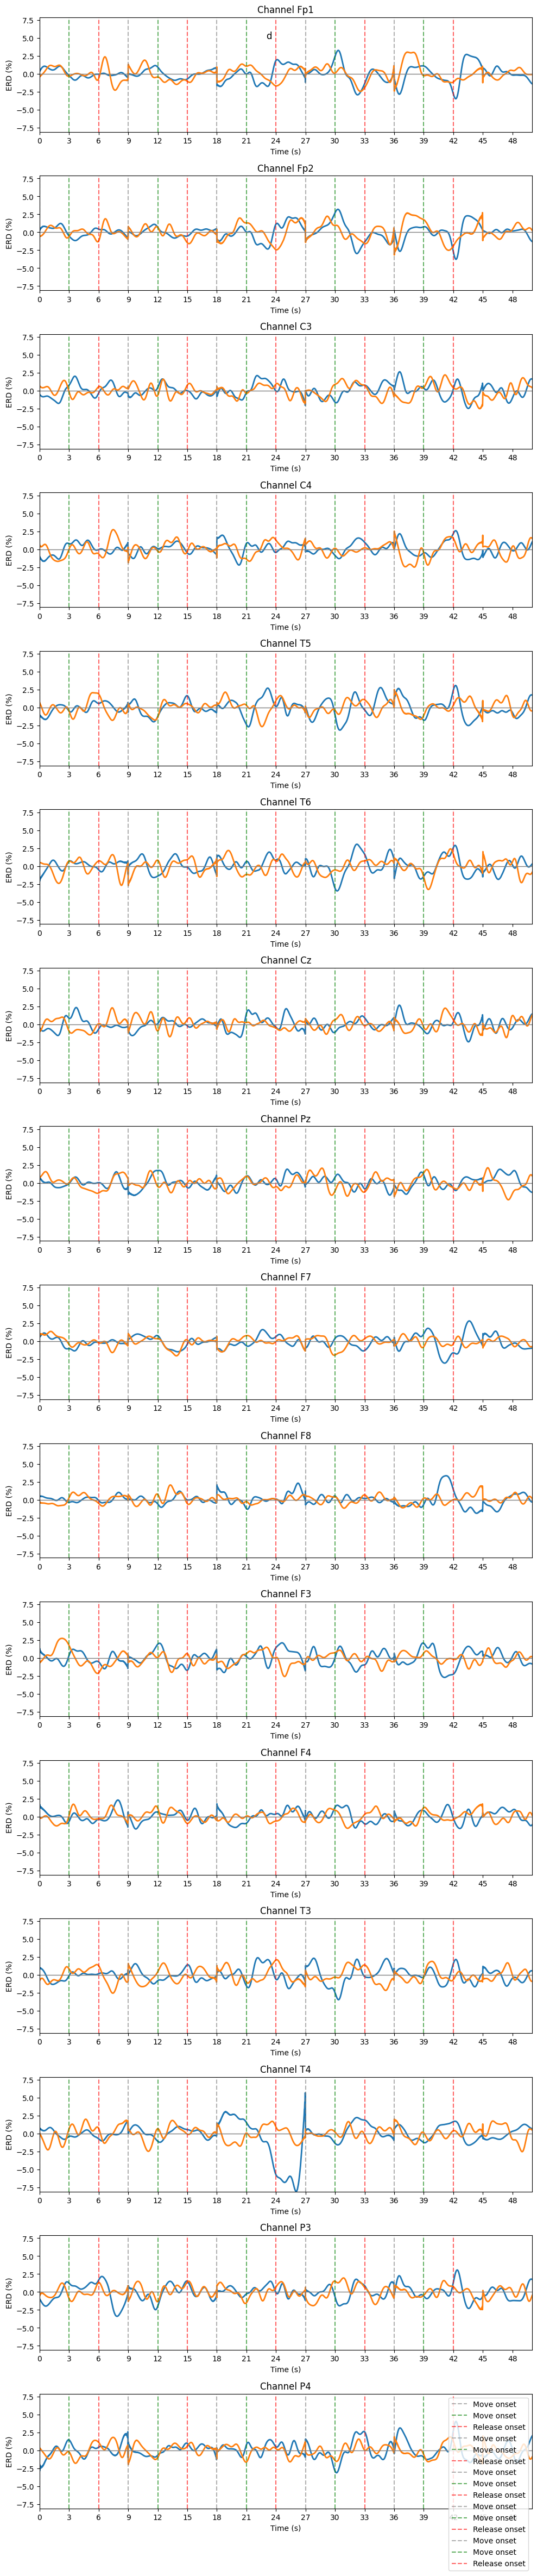

In [ ]:
#-------------#
# NEWEST PLOT #
#-------------#

def plot_compare_data_means(data1, data2, fs, title, list_of_channels):
    n_samples, n_channels = data1.shape
    time = np.arange(n_samples) / fs

    ymax = np.max((np.max(data1), np.max(data2)))
    ymin = np.min((np.min(data1), np.min(data2)))

    if list_of_channels is not None:
        display_channels = list_of_channels
        num_rows = len(display_channels)
        print(display_channels)
    else:
        display_channels = np.arange(n_channels)
        num_rows = n_channels
        print(display_channels)

    fig, axes = plt.subplots(nrows = num_rows, ncols = 1, figsize = (10, 3 * num_rows))

    for i, ch in enumerate(display_channels):
        ax = axes[i]

        ax.plot(time, data1[:, ch], linewidth=2)
        ax.plot(time, data2[:, ch], linewidth=2)

        for t in range(5):
            # 0, 3, 6, 9,   9, 12, 15, 18,   18, 21, 24, 27
            th = t*9
            ax.axvline(0+th, linestyle="--", color="grey", alpha=0.6, label="Move onset")
            ax.axvline(3+th, linestyle="--", color="green", alpha=0.6, label="Move onset")
            ax.axvline(6+th, linestyle="--", color="red", alpha=0.6, label="Release onset")

        ax.axhline(0, color="gray", linewidth=1)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("ERD (%)")
        ax.set_title(f'Channel {EEG_CH_NAMES[ch]}')

        ax.set_ylim(ymin, ymax)
        ax.set_xticks(np.arange(0, 50, 3))
        ax.set_xlim(0, 50)
    
    fig.suptitle(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_erd_single_trials(erd_all, fs, ch_idx, n_trials=20):
    n_epochs, n_samples, _ = erd_all.shape
    time = np.arange(n_samples) / fs

    plt.figure(figsize=(10, 6))

    for i in range(min(n_trials, n_epochs)):
        plt.plot(time, erd_all[i, :, ch_idx], alpha=0.3)

    plt.axvline(3, linestyle="--", color="k", alpha=0.6)
    plt.axvline(6, linestyle="--", color="k", alpha=0.6)
    plt.axhline(0, color="gray", linewidth=1)

    plt.xlabel("Time (s)")
    plt.ylabel("ERD (%)")
    plt.title(f"Single-trial ERD (Channel {ch_idx})")
    plt.tight_layout()
    plt.show()

def plot_erd_time_frequency(
    erd_tf_mean,
    freqs,
    fs,
    ch_idx,
    vmin=-50,
    vmax=50,
    title="ERD Time-Frequency"
):
    """
    erd_tf_mean: (F, T, C)
    freqs: (F,)
    """
    F, T, _ = erd_tf_mean.shape
    time = np.arange(T) / fs

    plt.figure(figsize=(10, 4))
    plt.pcolormesh(
        time,
        freqs,
        erd_tf_mean[:, :, ch_idx],
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    plt.axvline(3, color="k", linestyle="--", linewidth=1)
    plt.axvline(6, color="k", linestyle="--", linewidth=1)

    plt.colorbar(label="ERD (%)")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_erd_band_time(
    erd_tf_mean,
    freqs,
    fs,
    ch_idx,
    title="Band-averaged ERD"
):
    """
    erd_tf_mean: (F, T, C)
    """
    time = np.arange(erd_tf_mean.shape[1]) / fs

    erd_band = erd_tf_mean[:, :, ch_idx].mean(axis=0)  # avg over freq

    plt.figure(figsize=(10, 4))
    plt.plot(time, erd_band, linewidth=2)

    plt.axvline(3, color="k", linestyle="--", label="Move onset")
    plt.axvline(6, color="k", linestyle="--", label="Release onset")
    plt.axhline(0, color="gray", linewidth=1)

    plt.xlabel("Time (s)")
    plt.ylabel("ERD (%)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

list_of_channels = [2, 3, 6]

plot_erd_single_trials()

## Plot functions

In [98]:
def plot_mrcp_across_channels_separate(epoch_mean):
    """
    Plots the MRCP for each channel.

    Args:
        mrcp (np.ndarray): 2D array of shape (n_samples, n_channels)
    """
    fig, axes = plt.subplots(EEG_NUM_CH, len(epoch_mean), figsize = (20, 40))
    
    for i, finger in enumerate(epoch_mean.keys()):
        time = np.arange(epoch_mean[finger].shape[0]) / EEG_FREQ
        mrcp = compute_mrcp(epoch_mean[finger])

        for ch in range(EEG_NUM_CH):
            axes[ch, i].plot(time, mrcp[:, ch])
            axes[ch, i].set_title(f'MRCP - For {finger} at channel {EEG_CH_NAMES[ch]}')
            
            axes[ch, i].set_xlabel('Time')
            axes[ch, i].set_ylabel('Amplitude [a.u]')

            axes[ch, i].axhline(0, color='black', linestyle = '-', linewidth=1)  # baseline line
            axes[ch, i].axvline(2, color='green', linestyle='-.', label="Contract")
            axes[ch, i].axvline(7, color='red', linestyle='--', label="Release")
            axes[ch, i].legend(loc='upper right')
        
    fig.tight_layout()

def plot_mrcp_across_channels_together(epoch_mean, single_plot_flag = 0):
    """
    Plots the MRCP for each channel.

    Args:
        mrcp (np.ndarray): 2D array of shape (n_samples, n_channels)
    """
    fig, axes = plt.subplots(EEG_NUM_CH, 1, figsize = (10, 40))
    single_plot_flag = 0

    for finger in epoch_mean.keys():
        time = np.arange(epoch_mean[finger].shape[0]) / EEG_FREQ
        mrcp = compute_mrcp(epoch_mean[finger])

        for ch in range(EEG_NUM_CH):
            axes[ch].plot(time, mrcp[:, ch], label = finger)
            
            if single_plot_flag == 1:
                axes[ch].set_title(f'MRCP - For {finger} at channel {EEG_CH_NAMES[ch]}')
                
                axes[ch].set_xlabel('Time')
                axes[ch].set_ylabel('Amplitude [a.u]')
                
                axes[ch].axhline(0, color='black', linestyle = '-', linewidth=1)  # baseline line
                axes[ch].axvline(2, color='green', linestyle='-.', label="Contract")
                axes[ch].axvline(7, color='red', linestyle='--', label="Release")
                axes[ch].legend(loc='lower left')
        
        single_plot_flag = 1
        
    fig.tight_layout()

def plot_mean_epoch_across_channels(data, set_time = None):
    n_channels = 16

    fig, axes = plt.subplots(n_channels, len(data), figsize = (6, 40))
    for i, finger in enumerate(data.keys()):
        time = np.arange(data[finger].shape[0]) / EEG_FREQ

        ymax = np.max(data[finger])
        ymin = np.min(data[finger])
        for ch in range(n_channels):

            if len(data.keys()) == 1:
                ax = axes[ch]
            else:
                ax = axes[ch, i]

            ax.plot(time, data[finger][:,ch])
            ax.set_title(f'For {finger} at channel {EEG_CH_NAMES[ch]}')
            
            ax.set_xlabel('Time')
            ax.set_ylabel('Amplitude [a.u]')
            
            ax.set_ylim(ymin, ymax)
            ax.set_xlim(0, set_time)

            ax.axhline(0, color='black')
            for t in range(set_time):
                ax.axvline(t*3, color='green', linestyle='-.', label="Contract")
                #ax.axvline(6, color='red', linestyle='--', label="Release")
            #ax.legend(loc='upper right')

    fig.tight_layout()

def plot_mean_epoch_single_channels(data, ch1 = 0, ch2 = 1, finger1 = None, finger2 = None):

    
    fig, axs = plt.subplots(
    1, 2,
    figsize=(mm_to_inches(162), mm_to_inches(60)),
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )
    print('Channel Name :', EEG_CH_NAMES[ch1], 'and', EEG_CH_NAMES[ch2])
    
    time = np.arange(data[finger1].shape[0]) / EEG_FREQ

    axs[0].plot(time, data[finger1][:,ch1], color='royalblue', linewidth=1.0, label='Index finger')
    axs[0].set_xlim([0, 8])
    axs[0].set_ylim([-0.6, 0.6])
    axs[0].set_xticks(np.arange(0.0, 8.01, 1.0))
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Standardized EEG (a.u)')
    axs[0].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(time, data[finger2][:,ch2], color='royalblue', linewidth=1.0, label='Index finger')
    axs[1].set_xlim([0, 8])
    #axs[1].set_ylim([-0.6, 0.6])
    axs[1].set_xticks(np.arange(0.0, 8.01, 1.0))
    axs[1].set_xlabel('Time (s)')
    #axs[1].set_ylabel('Standardized EEG (a.u)')
    axs[1].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].grid(True, alpha=0.3)
    
    plt.savefig(fr'images\Nicklas_wrist_EMG\Mean_EEG_epoch_{finger1}_{EEG_CH_NAMES[ch1]}_and_{finger2}_{EEG_CH_NAMES[ch2]}_report.pdf')

def plot_EEG_sequence_across_channels(data, st = 0, end = 9, fs = 125):
    xmin = st * fs
    xmax = end * fs
    n_samples, n_channels = data[xmin:xmax, :].shape
    col_size = 2 * n_channels
    row_size = 0.009 * n_samples 
    time = np.arange(n_samples) / fs

    fig, ax = plt.subplots(nrows = n_channels, ncols = 1, figsize = (row_size, col_size))
    
    for i in range(n_channels):
        ax[i].plot(time, data[xmin:xmax, i], label = f"EEG ch {EEG_CH_NAMES[i]}")
        ax[i].set_xticks(np.arange(st, end, 1))

    plt.show()

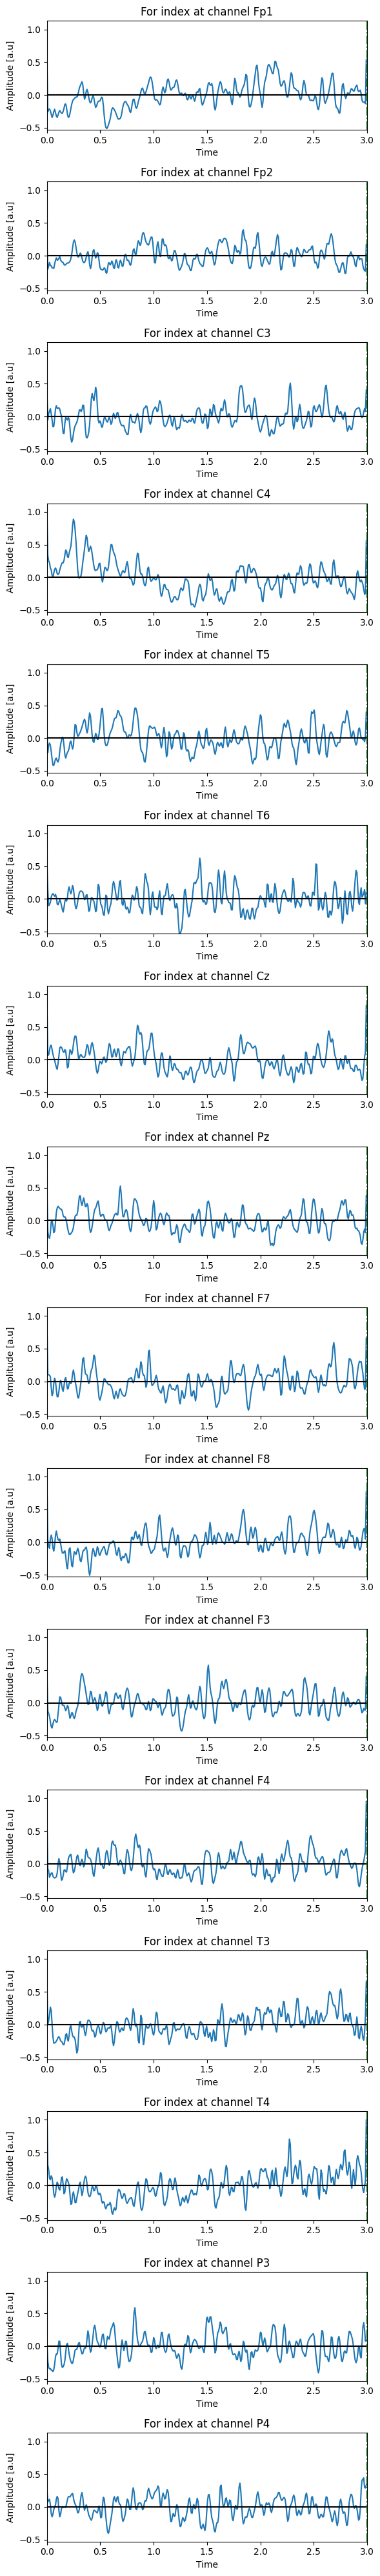

In [108]:
EEG_dict_epoch_mean = {}
EEG_dict = {}
EEG_dict_epoch_mean['index'] = EEG_epoch_mean
EEG_dict['index'] = EEG
plot_mean_epoch_across_channels(EEG_dict_epoch_mean, set_time = 3)  # uden car

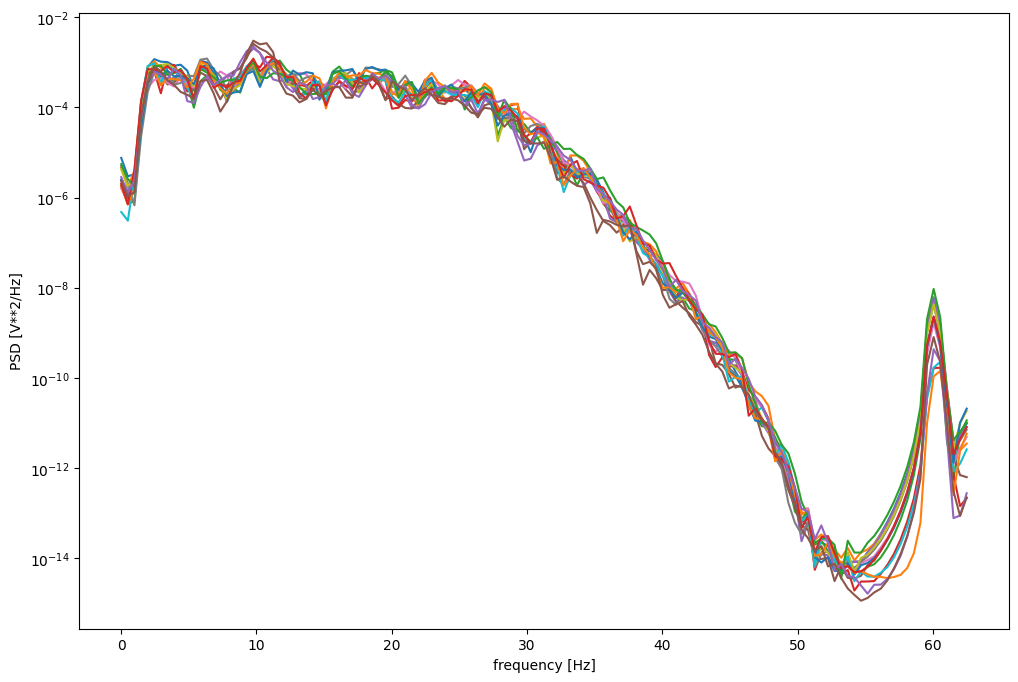

In [41]:
from scipy.signal import welch

plt.figure(figsize = (12, 8))

f, Pxx_den = welch(EEG_index_epoch[:, :, :].mean(axis=0), EEG_FREQ, axis=0)
plt.semilogy(f, Pxx_den)
#plt.ylim([0.5e-4, 1])
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()


## Visualize topoplot with MNE

### 1. Load your custom electrode positions (.sfp)

In [ ]:
channel_location_dir = str(parent_dir) + "\\utilities\\electrode_positions_16channel_modifed.sfp"

montage = mne.channels.read_custom_montage(channel_location_dir)
montage

### 2. Create MNE Info object

In [ ]:
ch_names = montage.ch_names
n_channels = len(ch_names)

info = mne.create_info(
    ch_names = ch_names,
    sfreq = EEG_FREQ,
    ch_types = 'eeg'
)

# Attach your custom montage
info.set_montage(montage)

### EKSTRA: ERD topo plot

In [ ]:
ERD_T = MRCP.T # shape -> (channels, samples)

evoked = mne.EvokedArray(ERD_T, info, tmin=0)

In [ ]:
# Keep to remain the scale
vmax = np.percentile(np.abs(ERD_T), 100)
vlim = (-vmax, vmax)

In [ ]:
times = [2.8, 5.0, 7.8]   # seconds relative to your epoch start

fig = evoked.plot_topomap(
    times=times,
    ch_type='eeg',
    cmap='RdBu_r',
    size=1,
    time_unit='s',
    scalings=1,
    vlim=vlim,
    show=True
)


fig.savefig("mrcp_topomap_index.pdf", dpi=400, bbox_inches="tight")

### 3. Convert your numpy epochs into MNE Epochs

In [ ]:
# Reshape, because MNE needs the dimensions of: (n_epochs, n_channels, n_samples)
select_data_epoch_index = EEG_epoch['index'].transpose(0, 2, 1).copy() * 1e-6   # convert µV → V
select_data_epoch_thumb = EEG_epoch['thumb'].transpose(0, 2, 1).copy() * 1e-6   # convert µV → V 

epochs_mne_index = mne.EpochsArray(select_data_epoch_index, info=info, verbose=False)
epochs_mne_thumb = mne.EpochsArray(select_data_epoch_thumb, info=info, verbose=False)

# Compute evoked response (average across epochs)
evoked_index = epochs_mne_index.average()
evoked_thumb = epochs_mne_thumb.average()

In [ ]:
print(f"select_data_epoch_index shape: {select_data_epoch_index.data.shape}\n"
      f"evoked_index shape: {evoked_index.data.shape}")

### 4. Create a beautiful topoplot

In [ ]:
# Time (in seconds) you want to visualize
time_to_plot = 8

fig = evoked_index.plot_topomap(
    times=[time_to_plot],
    ch_type='eeg',
    cmap='RdBu_r',
    size=3,
    show=False
)

plt.show()

### 5. Multiple topoplots across time

In [ ]:
times = [1, 2, 7]  # seconds

fig = evoked_index.plot_topomap(
    times=times,
    ch_type='eeg',
    cmap='RdBu_r',
    size=3,
    show=False
)

plt.show()

### 7. Compare two classes: thumb vs index

In [ ]:
# Difference map
evoked_diff = mne.combine_evoked([evoked_index, evoked_thumb], weights=[1, -1])

evoked_diff.plot_topomap(times=[0.3, 0.5, 0.7], cmap='RdBu_r', size=3)


## Step-by-step solution: windowed topomaps

## 1. Extract window-averaged topographies

In [ ]:
# Define time window 
time_windows = [
    (0.6, 1.0),
    (2.6, 3.0),
    (7.6, 8.0)
]

topomaps = []
times_for_plot = []

for tmin, tmax in time_windows:
    # Crop evoked to window
    evoked_win = evoked_index.copy().crop(tmin=tmin, tmax=tmax)

    # Average across time → (n_channels,)
    topo = evoked_win.data.mean(axis=1)
    topomaps.append(topo)

    # For labeling only
    times_for_plot.append((tmin + tmax) / 2)

## 3. Plot them as a row of scalp maps

In [ ]:
fig, axes = plt.subplots(1, len(topomaps), figsize=(12, 4))
vlim = max(abs(np.concatenate(topomaps)))

for i, topo in enumerate(topomaps):
    im, _ = mne.viz.plot_topomap(
        topo,
        evoked_index.info,
        axes=axes[i],
        cmap='RdBu_r',
        vlim=(-vlim, vlim),
        show=False
    )
    axes[i].set_title(f"{time_windows[i][0]}–{time_windows[i][1]} s")

# ---- Add shared colorbar ----
cbar = fig.colorbar(im, ax=axes, shrink=0.7)
cbar.set_label("Amplitude (µV)")

#plt.tight_layout()
plt.show()
